## Grape Disease Classification Classification


# Table of Contents

*   **1. Introduction**
*   **2. Dataset Analysis**
    *   2.1. The Oxford-IIIT Pet Dataset
    *   2.2. Exploratory Data Analysis
    *   2.3. Data Preprocessing and Augmentation
*   **3. ResNets**
    *   3.1. Residual Connections
    *   3.2. ResNet18 and ResNet34 Architectures
    *   3.3. Implementing ResNets in PyTorch
*   **4. Training Experiments**
    *   4.1. Training a ResNet18 from Scratch
    *   4.2. Transfer Learning: Fine-tuned ResNet18
        *   4.2.1. A Two-Stage Fine-Tuning Strategy
        *   4.2.2. Fine-tuning a Larger Model (ResNet34)
    *   4.3. Knowledge Distillation
        *   4.3.1. Knowledge Distillation Theory
        *   4.3.2. Distilling to a ResNet18 Trained from Scratch
        *   4.3.3. Combining Fine-tuning and Distillation
        *   4.3.4. Beyond Classic Distillation
    *   4.4. Models Interpretation and Visualisation
        *   4.4.1. Confusion Matrix Comparison
        *   4.4.2. Visualising Feature Space with t-SNE
        *   4.4.3. First Layer Filter Visualisation
        *   4.4.4. Intermediate Feature Map Visualisation
    *   4.5. Training Experiments Conclusions
*   **5. Model Compression Experiments**
    *   5.1. Model Quantisation
        *   5.1.1. Fundamentals of Neural Network Quantisation
        *   5.1.2. The Post-Training Quantisation (PTQ) Process
        *   5.1.3. Beyond Post-Training Quantisation
    *   5.2. Pruning
        *   5.2.1. Iterative Magnitude-based Unstructured Pruning
        *   5.2.2. Beyond Unstructured Pruning
    *   5.3. Quantisation vs. Pruning
*   **6. Conclusions**

# 1. Introduction


# 2. Dataset Analysis

### 2.1. Grape Leaf Disease Dataset

🌿 Overview: this dataset contains images of infected and healthy grape leaves, categorized into 4 distinct classes. The primary goal is to enable machine learning models to accurately detect and classify grape plant diseases across three major diseases: Black Measles, Black Rot, Healthy, Isariopsis Leaf Spot
https://www.kaggle.com/datasets/bmshahriaalam/grape-leaf-disease

A detailed breakdown of the disease classes and the distribution of images across the standard training and test splits is provided in the table below, which has been adapted from the original dataset.

| Disease Class | Training Images | Test Images | Total Images |
| :--- | :---: | :---: | :---: |
| Black Rot | ~1,805 | ~451 | ~2,256 |
| Esca (Black Measles) | ~1,805 | ~451 | ~2,256 |
| Healthy | ~1,806 | ~452 | ~2,258 |
| Leaf Blight (Isariopsis Leaf Spot) | ~1,806 | ~451 | ~2,257 |
| --- | --- | --- | --- |
| **Total Disease Classes** | **4** | **4** | **4** |
| **Total Images** | **7,222** | **1,805** | **9,027** |

[*Table 1: Data composition of the 4 grape disease classes. The dataset maintains a relatively balanced distribution across all disease categories, with approximately 2,250 images per class.*]


### 2.2. Exploratory Data Analysis

As indicated by the table in the previous section, the Grape Leaf Disease dataset is well-balanced across its 4 disease classes. This section performs a brief exploratory analysis to confirm the dataset's structure and visualize some of its contents.

For practicality and reproducibility, the dataset is loaded directly using the `torchvision.datasets.ImageFolder` class, which automatically organizes images into classes based on the directory structure. The dataset is sourced from the local directory at `/home/ubuntu/GddAi/dd_cnn/dataset/grape-disease/` with separate folders for training and testing data.


✓ Jupyter Notebook is working!
✓ Python version: 3.10.12 (main, Nov  4 2025, 08:48:33) [GCC 11.4.0]
✓ NumPy version: 2.1.2
✓ NumPy calculation: Sum of [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] = 15


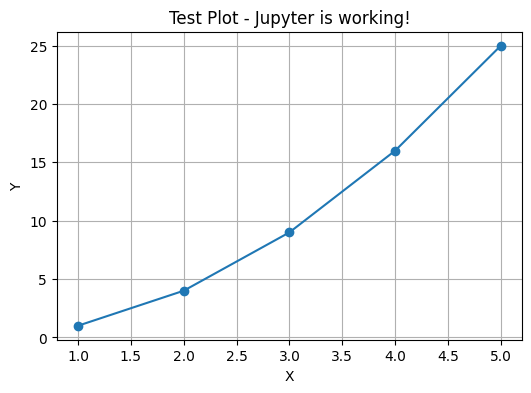

✓ All tests passed! Notebook is ready to use.


In [1]:
# Test to check if Jupyter Notebook is working correctly
import sys
import numpy as np
import matplotlib.pyplot as plt

print("✓ Jupyter Notebook is working!")
print(f"✓ Python version: {sys.version}")
print(f"✓ NumPy version: {np.__version__}")

# Simple test calculation
test_array = np.array([1, 2, 3, 4, 5])
print(f"✓ NumPy calculation: Sum of {list(test_array)} = {test_array.sum()}")

# Simple test plot
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3, 4, 5], [1, 4, 9, 16, 25], 'o-')
plt.title("Test Plot - Jupyter is working!")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

print("✓ All tests passed! Notebook is ready to use.")

First of all, let's import some libraries that I will use throughout the notebook:

In [2]:
# Install missing packages with proper CUDA support
packages_to_check = {
    'gdown': 'gdown',
    'tqdm': 'tqdm',
    'ipywidgets': 'ipywidgets',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'numpy': 'numpy'
}

for package_name, pip_name in packages_to_check.items():
    try:
        if package_name == 'sklearn':
            from sklearn.metrics import confusion_matrix  # Test specific import
        elif package_name == 'matplotlib':
            import matplotlib.pyplot as plt  # Test specific import
        else:
            __import__(package_name)
        print(f"{package_name} already available")
    except ImportError:
        print(f"Installing {pip_name}...")
        !pip install -q {pip_name}

# Check PyTorch and install if missing with auto-detected CUDA support
try:
    import torch
    import torchvision
    print(f"PyTorch {torch.__version__} already installed")
    if torch.cuda.is_available():
        print(f"CUDA {torch.version.cuda} support available")
        print(f"GPU device: {torch.cuda.get_device_name(0)}")
except ImportError:
    print("PyTorch not found. Detecting system CUDA version...")

    # Detect CUDA version
    import subprocess
    cuda_version = None
    try:
        # Try nvidia-smi first
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        if result.returncode == 0:
            for line in result.stdout.split('\n'):
                if 'CUDA Version:' in line:
                    cuda_version = line.split('CUDA Version:')[1].strip().split()[0]
                    break

        # Try nvcc as backup
        if not cuda_version:
            result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
            if result.returncode == 0:
                for line in result.stdout.split('\n'):
                    if 'release' in line.lower():
                        # Extract version like "12.5" from "release 12.5, V12.5.82"
                        cuda_version = line.split('release')[1].split(',')[0].strip()
                        break
    except:
        pass

    # Determine PyTorch index URL based on CUDA version
    if cuda_version:
        major_minor = cuda_version.split('.')[:2]
        cuda_short = ''.join(major_minor)  # "12.5" -> "125", "12.4" -> "124"
        index_url = f"https://download.pytorch.org/whl/cu{cuda_short}"
        print(f"Installing PyTorch with CUDA {cuda_version} support...")
    else:
        index_url = "https://download.pytorch.org/whl/cpu"
        print("CUDA not detected, installing CPU-only PyTorch...")

    !pip install -q torch torchvision torchaudio --index-url {index_url}

# Verify all imports work
print("\nVerifying all imports...")
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import DataLoader, Dataset, Subset
    from torch.quantization import fuse_modules, get_default_qconfig, get_default_qat_qconfig, prepare, prepare_qat, convert
    import torch.nn.utils.prune as prune
    import torchvision
    import torchvision.transforms as transforms
    import torchvision.models as models
    from torchvision.models.resnet import ResNet
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    from sklearn.model_selection import train_test_split
    import numpy as np
    
    # Try to import tqdm for notebooks with fallback to regular tqdm
    try:
        from tqdm.notebook import tqdm
        print("Using tqdm.notebook (with progress bar widgets)")
    except ImportError:
        from tqdm import tqdm
        print("Using standard tqdm (ipywidgets not available)")
    
    import datetime
    import copy
    import os
    import gdown
    import random
    import time
    import pandas as pd
    import seaborn as sns
    from sklearn.manifold import TSNE
    from torch.amp import autocast, GradScaler

    print("All imports successful!")

    # Show system info
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU: {torch.cuda.get_device_name(0)}")

except ImportError as e:
    print(f" Import error: {e}")


gdown already available
tqdm already available
ipywidgets already available
seaborn already available
sklearn already available
pandas already available
matplotlib already available
numpy already available
seaborn already available
sklearn already available
pandas already available
matplotlib already available
numpy already available
PyTorch 2.5.1+cu121 already installed
CUDA 12.1 support available
GPU device: NVIDIA L4

Verifying all imports...
Using tqdm.notebook (with progress bar widgets)
All imports successful!
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU: NVIDIA L4
PyTorch 2.5.1+cu121 already installed
CUDA 12.1 support available
GPU device: NVIDIA L4

Verifying all imports...
Using tqdm.notebook (with progress bar widgets)
All imports successful!
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU: NVIDIA L4


In [3]:
# Load the raw datasets

try:
    print("loading the dataset...")
    #raw_train_val_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', download=True)
    raw_train_val_dataset = torchvision.datasets.ImageFolder(
        root='/home/ubuntu/GddAi/dd_cnn/dataset/grape-disease/train'
    )
    raw_test_dataset = torchvision.datasets.ImageFolder(
        root='/home/ubuntu/GddAi/dd_cnn/dataset/grape-disease/test'
    )

    #raw_test_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='test', download=True)
    print("Dataset loaded successfully.")
except Exception as e:
    print(f"An error occurred during dataset download: {e}")
    print("Please check your internet connection or storage space.")

loading the dataset...
Dataset loaded successfully.


Verifying the number of images loaded by `torchvision` aligns with the figures reported in the original publication ([Mandal & Gouda, 2024](#mandal2024vineyard)). This ensures that the correct and complete dataset.

In [4]:
# Verify the dataset sizes
train_val_size = len(raw_train_val_dataset)
test_size = len(raw_test_dataset)
total_size = train_val_size + test_size

print(f"Verification of Dataset Size:")
print("-" * 30)
print(f"Images in Training & Validation set: {train_val_size}")
print(f"Images in Test set: {test_size}")
print(f"Total images in the dataset: {total_size}")

# The paper's table shows a total of 7349 images.
# The torchvision split uses the same convention.
if train_val_size == 7222 and test_size == 1805:
    print("\n The dataset size matches the official numbers from the paper.")
else:
    print("\n Warning: The dataset size does not match the official numbers.")

Verification of Dataset Size:
------------------------------
Images in Training & Validation set: 7222
Images in Test set: 1805
Total images in the dataset: 9027

 The dataset size matches the official numbers from the paper.


With the dataset size confirmed, the next step is to visualise some sample images. This will help to get a better appreciation for the fine-grained nature of the classification task.

In [5]:
# Count images per class
from collections import defaultdict

class_counts = defaultdict(int)
for _, label in raw_train_val_dataset:
    class_counts[raw_train_val_dataset.classes[label]] += 1

print("Number of images per class in Train set:")
print("-" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")



test_class_counts = defaultdict(int)
for _, label in raw_test_dataset:
       test_class_counts[raw_test_dataset.classes[label]] += 1
print("\nNumber of images per class in Test set:")
print("-" * 45)
for class_name, count in test_class_counts.items():
 print(f"{class_name}: {count}")

Number of images per class in Train set:
---------------------------------------------
Black_rot: 1888
Esca: 1920
Healthy: 1692
Leaf_blight: 1722

Number of images per class in Test set:
---------------------------------------------
Black_rot: 472
Esca: 480
Healthy: 423
Leaf_blight: 430

Number of images per class in Test set:
---------------------------------------------
Black_rot: 472
Esca: 480
Healthy: 423
Leaf_blight: 430


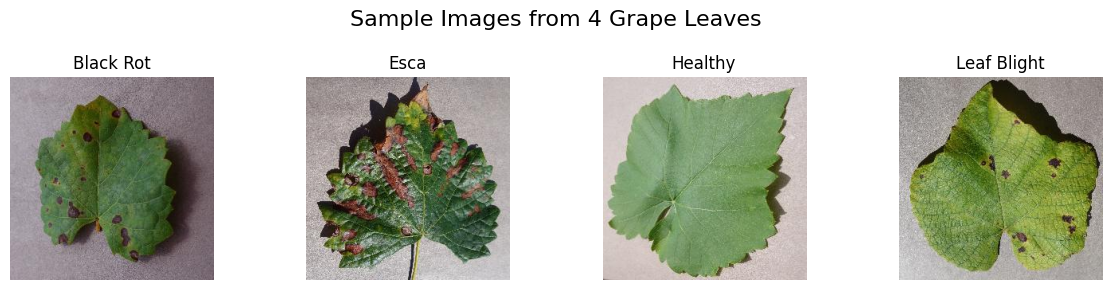

In [6]:
# --- Configuration for the visualization ---
GrapeLeafClasses = 4  
ncols = 4
nrows = int(np.ceil(GrapeLeafClasses / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Get the list of class names from the dataset
class_names_train = raw_train_val_dataset.classes
class_names = [name.replace("Grape___", "") for name in class_names_train]
num_classes = len(class_names)

# Find one image for each of the first `GrapeLeafClasses` classes
# This is more efficient than iterating through the whole dataset for each class
class_to_image = {}
for img, label in raw_train_val_dataset:
    if label not in class_to_image and len(class_to_image) < GrapeLeafClasses:
        class_to_image[label] = img
    # Optimization: stop once and you got one image for each required class
    if len(class_to_image) == GrapeLeafClasses:
        break

# Display the images
for i, (label, img) in enumerate(class_to_image.items()):
    ax = axes[i]
    ax.imshow(img)
    # Format title for better readability
    title = class_names[label].replace('_', ' ').title()
    ax.set_title(title)
    ax.axis('off')

# Hide any unused subplots
for i in range(GrapeLeafClasses, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Sample Images from {GrapeLeafClasses} Grape Leaves', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

Checking the image sizes (heights and widths) across a sample of the training set

In [7]:
# Analyze image sizes from the raw dataset (before resizing)
print("Analyzing original image dimensions...")

# Sample a subset of images to check dimensions
sample_indices = random.sample(range(len(raw_train_val_dataset)), min(100, len(raw_train_val_dataset)))

unique_dimensions = set()
for i in sample_indices:
    img, _ = raw_train_val_dataset[i]  # img is a PIL Image object
    unique_dimensions.add((img.width, img.height))

# Display the results
print(f"\nImage Dimension Analysis (from {len(sample_indices)} samples):")
print("-" * 50)
if len(unique_dimensions) == 1:
    width, height = list(unique_dimensions)[0]
    print(f"All images have uniform dimensions: {width}x{height} pixels")
    print(f"Aspect ratio: {width/height:.2f}")
else:
    print(f"Found {len(unique_dimensions)} different image dimensions:")
    for width, height in sorted(unique_dimensions):
        print(f"  - {width}x{height} pixels (aspect ratio: {width/height:.2f})")


Analyzing original image dimensions...

Image Dimension Analysis (from 100 samples):
--------------------------------------------------
All images have uniform dimensions: 256x256 pixels
Aspect ratio: 1.00


The analysis reveals that all images in the dataset have uniform 256x256 pixel dimensions with 1.0 aspect ratios, meaning they're all square. This consistency simplifies preprocessing since no resizing or cropping is needed, unlike datasets with variable dimensions.

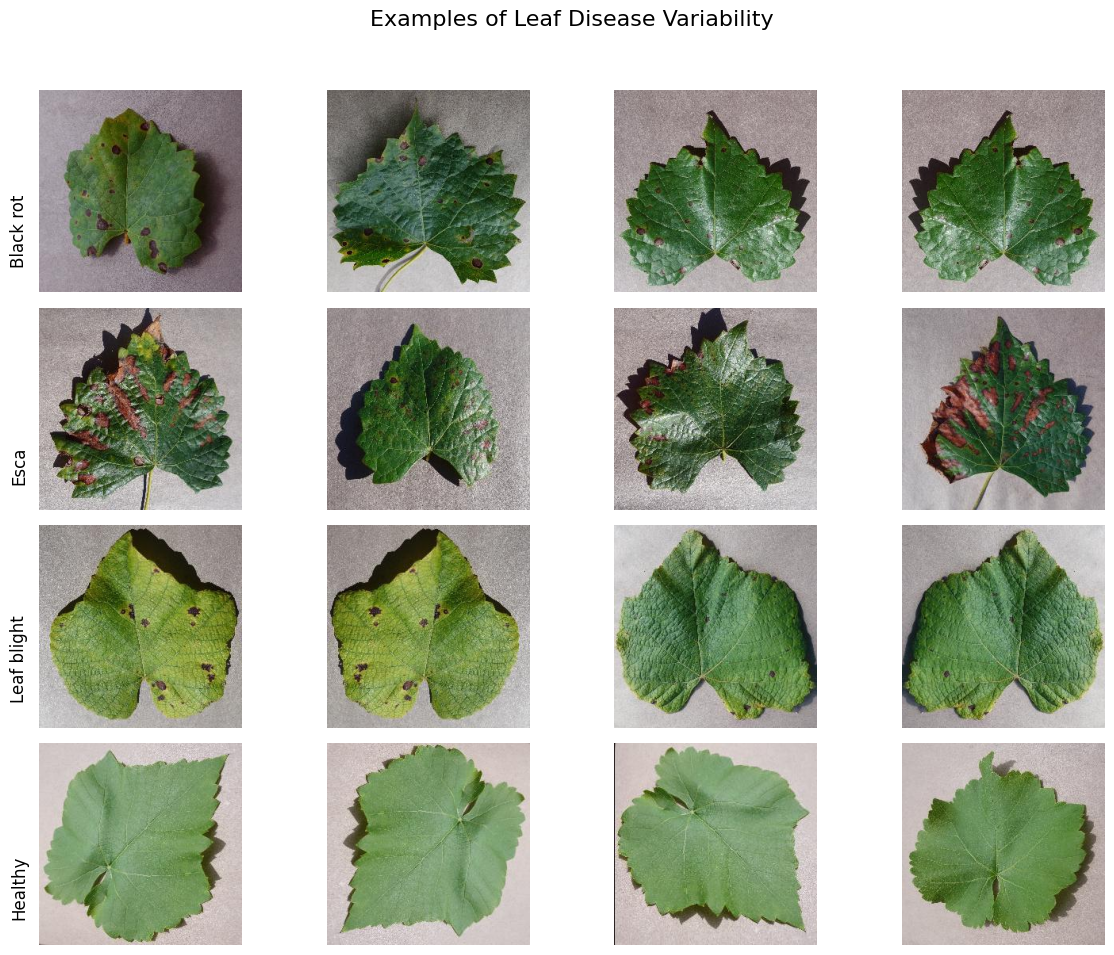

In [8]:
Leaf_class_to_show = ['Black_rot', 'Esca', 'Leaf_blight', 'Healthy']
samples_per_class = 4

# Collect samples for the specified breeds
leaf_images = {Class: [] for Class in Leaf_class_to_show}
class_to_idx = raw_train_val_dataset.class_to_idx

for img, label in raw_train_val_dataset:
    # Reverse lookup to get the class name from the label index
    Class_images = raw_train_val_dataset.classes[label]
    if Class_images in Leaf_class_to_show and len(leaf_images[Class_images]) < samples_per_class:
        leaf_images[Class_images].append(img)

# Plotting 
fig, axes = plt.subplots(len(Leaf_class_to_show), samples_per_class, figsize=(12, 10))
fig.suptitle('Examples of Leaf Disease Variability', fontsize=16)

for i, Class_images in enumerate(Leaf_class_to_show):
    for j, img in enumerate(leaf_images[Class_images]):
        ax = axes[i, j]
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            # Set the leaf disease name as the row title
            ax.set_title(Class_images.replace('_', ' '), rotation=90, x=-0.1, y=0.1, size='large')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

As the images demonstrate, there is significant variation within each disease class. Factors such as disease severity, leaf position, lighting conditions, and the stage of infection contribute to substantial intra-class variability. This natural diversity in how diseases manifest on grape leaves, combined with the subtle visual differences between certain disease types (particularly in early stages), makes this classification task challenging yet realistic for agricultural applications.

Finally, it is worth noting the overall size of the dataset. With a total of **9,027** images – split into **7,222** for training and validation, and **1,805** for testing – this represents a moderately-sized dataset suitable for deep learning experiments. While this number of examples is sufficient for fine-tuning pre-trained models, training a deep neural network such as ResNet **from scratch** presents significant challenges. Deep models require substantial amounts of data to learn robust feature representations, and with limited examples, they are highly susceptible to overfitting. This inherent challenge in training with moderate-scale agricultural datasets directly motivates the following experiments, where  compare compare training from scratch against more data-efficient approaches like **transfer learning** (see **Section 4.2**) and **knowledge distillation** (see **Section 4.3**). These techniques are particularly valuable in agricultural AI applications where collecting and labeling large-scale datasets remains a significant practical constraint.


### 2.3. Data Preprocessing and Augmentation

Data preprocessing and augmentation are essential for training the networks effectively.

Data preprocessing and augmentation strategies vary throughout this project depending on the specific experimental requirements. Rather than presenting all variations upfront, the preprocessing pipeline is detailed at each experimental stage where it is most relevant.

A helper function is defined below to introduce and visualize the preprocessing pipelines throughout the experiments.


In [9]:
class UnNormalize(object):
    """Reverses the normalization on a tensor image for visualization."""
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be unnormalized.
        Returns:
            Tensor: Unnormalized image.
        """
        # Create a copy to avoid modifying the original tensor
        tensor = tensor.clone()
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

def visualize_transforms(dataset, transform, title):
    """
    Applies a given transformation pipeline to a few sample images and displays
    the original versus the augmented versions.
    """
    # Try to find normalization parameters
    normalize_transform = None
    mean, std = None, None

    # First, try to find Normalize in the direct pipeline
    for t in transform.transforms:
        if isinstance(t, transforms.Normalize):
            normalize_transform = t
            mean, std = t.mean, t.std
            break

    # If not found, check if there's a nested transform (like weights.transforms())
    if normalize_transform is None:
        for t in transform.transforms:
            if hasattr(t, 'transforms'):  # It's a nested Compose
                for nested_t in t.transforms:
                    if isinstance(nested_t, transforms.Normalize):
                        normalize_transform = nested_t
                        mean, std = nested_t.mean, nested_t.std
                        break
                if normalize_transform:
                    break

    # If still not found, use ImageNet defaults (common for pretrained models)
    if normalize_transform is None:
        print(f"Warning: Normalize transform not found. Using ImageNet defaults.")
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]

    un_normalizer = UnNormalize(mean=mean, std=std)

    # Get a few random images from the raw dataset
    num_images_to_show = 4
    indices = np.random.choice(len(dataset), num_images_to_show, replace=False)

    fig, axes = plt.subplots(num_images_to_show, 5, figsize=(15, 2.5 * num_images_to_show))
    fig.suptitle(title, fontsize=16)

    for i, idx in enumerate(indices):
        original_image, _ = dataset[idx]

        # Display the original image
        ax = axes[i, 0]
        ax.imshow(original_image)
        ax.set_title("Original")
        ax.axis('off')

        # Display 4 augmented versions
        for j in range(1, 5):
            ax = axes[i, j]
            augmented_tensor = transform(original_image)
            unnormalized_tensor = un_normalizer(augmented_tensor.clone())

            # Clamp values to [0, 1] range for display
            unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)

            augmented_image_display = unnormalized_tensor.permute(1, 2, 0)
            ax.imshow(augmented_image_display)
            ax.set_title(f"Augmented {j}")
            ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [34]:
class UnNormalize(object):
    """Reverses the normalization on a tensor image for visualization."""
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be unnormalized.
        Returns:
            Tensor: Unnormalized image.
        """
        # Create a copy to avoid modifying the original tensor
        tensor = tensor.clone()
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

def visualize_transforms(dataset, transform, title):
    """
    Applies each transformation individually to sample images and displays
    the original image along with each individual transformation effect.
    """
    # Try to find normalization parameters
    normalize_transform = None
    mean, std = None, None

    # First, try to find Normalize in the direct pipeline
    for t in transform.transforms:
        if isinstance(t, transforms.Normalize):
            normalize_transform = t
            mean, std = t.mean, t.std
            break

    # If not found, check if there's a nested transform (like weights.transforms())
    if normalize_transform is None:
        for t in transform.transforms:
            if hasattr(t, 'transforms'):  # It's a nested Compose
                for nested_t in t.transforms:
                    if isinstance(nested_t, transforms.Normalize):
                        normalize_transform = nested_t
                        mean, std = nested_t.mean, nested_t.std
                        break
                if normalize_transform:
                    break

    # If still not found, use ImageNet defaults (common for pretrained models)
    if normalize_transform is None:
        print(f"Warning: Normalize transform not found. Using ImageNet defaults.")
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]

    un_normalizer = UnNormalize(mean=mean, std=std)

    # Extract individual transforms from the pipeline (excluding normalization and tensor conversion)
    individual_transforms = []
    transform_names = []
    
    for t in transform.transforms:
        if isinstance(t, transforms.Normalize):
            continue  # Skip normalization as we'll apply it for display
        if isinstance(t, transforms.ToTensor):
            continue  # Skip ToTensor
        individual_transforms.append(t)
        # Get a readable name for the transform
        transform_name = type(t).__name__
        transform_names.append(transform_name)
    
    # Get a few random images from the raw dataset
    num_images_to_show = 3
    indices = np.random.choice(len(dataset), num_images_to_show, replace=False)
    
    # Number of columns: 1 original + individual transforms + 1 all combined
    num_cols = 1 + len(individual_transforms) + 1
    
    fig, axes = plt.subplots(num_images_to_show, num_cols, figsize=(2.5 * num_cols, 2.5 * num_images_to_show))
    fig.suptitle(title, fontsize=16)

    for i, idx in enumerate(indices):
        original_image, _ = dataset[idx]

        # Display the original image
        ax = axes[i, 0] if num_images_to_show > 1 else axes[0]
        ax.imshow(original_image)
        ax.set_title("Original")
        ax.axis('off')

        # Display each individual transformation
        for j, (ind_transform, trans_name) in enumerate(zip(individual_transforms, transform_names)):
            ax = axes[i, j + 1] if num_images_to_show > 1 else axes[j + 1]
            
            # Apply the transform
            transformed = ind_transform(original_image)
            
            # Check if the result is already a tensor
            if isinstance(transformed, torch.Tensor):
                # If it's already a tensor, just normalize it
                augmented_tensor = transforms.Normalize(mean=mean, std=std)(transformed)
            else:
                # If it's still a PIL Image, apply ToTensor and then Normalize
                single_transform = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize(mean=mean, std=std)
                ])
                augmented_tensor = single_transform(transformed)
            
            unnormalized_tensor = un_normalizer(augmented_tensor.clone())

            # Clamp values to [0, 1] range for display
            unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)

            augmented_image_display = unnormalized_tensor.permute(1, 2, 0)
            ax.imshow(augmented_image_display)
            ax.set_title(trans_name)
            ax.axis('off')
        
        # Display all transformations combined
        ax = axes[i, -1] if num_images_to_show > 1 else axes[-1]
        augmented_tensor = transform(original_image)
        unnormalized_tensor = un_normalizer(augmented_tensor.clone())

        # Clamp values to [0, 1] range for display
        unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)

        augmented_image_display = unnormalized_tensor.permute(1, 2, 0)
        ax.imshow(augmented_image_display)
        ax.set_title("All Combined")
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Global Utilities

Let’s also define a couple global utilities that we will use throughout the notebook:

In [11]:
def evaluate_model(model, data_loader, criterion, device, desc="Evaluating"):
    """A standardized evaluation function to be used across all experiments."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        pbar = tqdm(data_loader, desc=desc)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=torch.cuda.is_available()):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'Loss': f'{running_loss/total:.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    final_loss = running_loss / len(data_loader.dataset)
    final_acc = 100. * correct / total
    return final_loss, final_acc, all_preds, all_labels

def print_model_size(model, label):
    """Saves a model to a temporary file to measure its size on disk."""
    temp_path = f"temp_{label}.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    print(f"Size of {label} model: {size_mb:.2f} MB")
    os.remove(temp_path)
    return size_mb

Let’s also define a set of control flags and helper functions for skipping training sections and loading pre-trained results. This allows for faster experimentation by reusing models that have already been trained offline.

In [12]:

# Define some reusable functions to download a file from Google Drive and to load a training history from a CSV file
def download_from_gdrive(file_id, output_path, file_label):
    """Downloads a file from Google Drive if it doesn't already exist."""
    if not os.path.exists(output_path):
        print(f"Downloading {file_label} to '{output_path}'...")
        gdown.download(id=file_id, output=output_path, quiet=False)
        print(f"{file_label} download complete.")
    else:
        print(f"{file_label} file '{output_path}' already exists. Skipping download.")

def load_training_history_from_csv(log_path):
    """Loads a training history log from a CSV file into a dictionary of lists."""
    try:
        log_df = pd.read_csv(log_path)
        # Ensure all expected columns are present, fill with empty lists if not
        history = {
            'train_loss': log_df.get('train_loss', pd.Series([])).tolist(),
            'train_accuracy': log_df.get('train_accuracy', pd.Series([])).tolist(),
            'val_loss': log_df.get('val_loss', pd.Series([])).tolist(),
            'val_accuracy': log_df.get('val_accuracy', pd.Series([])).tolist(),
            'learning_rate': log_df.get('learning_rate', pd.Series([])).tolist()
        }
        if history['train_loss']:
             print(f"Successfully loaded training history for {len(history['train_loss'])} epochs from '{log_path}'.")
        else:
             print(f"Warning: Could not load complete history from '{log_path}'. Check file content.")
        return history
    except FileNotFoundError:
        print(f"Error: The log file '{log_path}' was not found.")
        # Return empty history to avoid crashing subsequent code
        return {key: [] for key in ['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'learning_rate']}

To ensure that our experimental results are consistent and can be reliably reproduced, we now set a global random seed.

The `set_seed` function:
* Sets the seed for Python's built-in `random` module and NumPy, in order to have some deterministic behavior.
* For PyTorch (and also GPU operations), we do not enforce a fully deterministic strategy, because we want to keep a good balance between execution reproducibility and performance.

We then call this function immediately to apply these settings for the remainder of the notebook.

In [13]:
# We ensure reproducibility in our experiments
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    print(f"Random seed set to {seed}")

# Set the seed for the entire notebook
SEED = 42
set_seed(SEED)

Random seed set to 42


# 4. Training Experiments

This section details the series of experiments conducted to train and improve a ResNet model for our task. Let's begin by establishing a performance baseline by training a ResNet18 from scratch. And then progressively incorporate more advanced techniques, including transfer learning and knowledge distillation, to systematically improve upon this baseline and analyse the effectiveness of each method.

## 4.1. Training a ResNet18 from Scratch

This experiment establishes a performance baseline by training a ResNet18 model from scratch.

To mitigate the challenges of training a deep network on a moderately-sized dataset, I employ a robust training regimen that includes strong data augmentation and various techniques which I have found to be the most efficient for this specific training.

I defined the core hyperparameters for our training pipeline in this central configuration block.

*   **Training Parameters**: Sets the number of epochs, batch size, and patience for early stopping (we keep validation accuracy as the monitored metric to know when to stop training if the model stops improving).

*   **Optimizer & Scheduler**: Configures the initial learning rate, weight decay for the AdamW optimizer, and the number of warm-up epochs to stabilize training early on (cf. following cells).

*   **Regularization Techniques**: A suite of methods to prevent overfitting and improve model generalization:
    *   **Label Smoothing**: Prevents the model from becoming overconfident by using "soft" labels (e.g. `[0.9, 0.05, 0.05]`) instead of hard one-hot labels (`[1, 0, 0]`), which can improve generalization.
    *   **MixUp**: A data augmentation strategy that creates new virtual training examples by taking a weighted linear combination of two random images and their corresponding labels. This encourages the model to learn smoother decision boundaries between classes.
    *   **Dropout**: The rate at which neurons are randomly set to zero during training to prevent feature co-adaptation.

In [14]:
# Hyperparameters and Configuration
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Training configuration
NUM_EPOCHS = 100
BATCH_SIZE = 64
PATIENCE = 30
MODEL_SAVE_PATH = 'from_scratch.pth'

# Optimizer & Scheduler configuration
LEARNING_RATE = 0.003
WEIGHT_DECAY = 5e-4
WARMUP_EPOCHS = 10

# Regularization configuration
LABEL_SMOOTHING = 0.1
DROPOUT_RATE = 0.5
USE_MIXUP = True
MIXUP_ALPHA = 0.4

Using device: cuda


I defined two distinct data transformation pipelines using `torchvision.transforms`.

* **Training Pipeline (`train_transform`)**: In order to prevent overfitting and improve generalization, I apply a strong data augmentation strategy. This pipeline includes aggressive geometric and colour transformations like `RandomResizedCrop`, `RandomRotation`, and `ColorJitter`. This approach artificially expands the diversity of our training data, which is critical when training a deep model on a moderately-sized dataset.

* **Validation/Test Pipeline (`test_transform`)**: This pipeline simply resizes and center-crops the images to the required `224x224` input size before normalization. Applying no random augmentations ensures that we get a consistent and reproducible measure of the model's performance.

In [15]:


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.3, 1.0)),  # Aggressive cropping
    transforms.RandomHorizontalFlip(p=0.5),  # 50% chance - FIXED
    transforms.RandomRotation(120),  # Strong rotation
    transforms.ColorJitter(brightness=0.6, contrast=0.6, saturation=0.6, hue=0.2),
    transforms.RandomGrayscale(p=0.3),  # 30% chance - FIXED (was destroying all color)
    transforms.RandomPerspective(distortion_scale=0.75, p=0.5),  # Strong perspective
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Let's visualize the effect of this custom augmentation pipeline on a few sample images. Notice how `RandomResizedCrop` changes the zoom and composition, while other transforms like `RandomHorizontalFlip`, `RandomRotation`, and `RandomPerspective` alter the orientation and spatial layout. `ColorJitter` and `RandomGrayscale` modify the color characteristics of the image.

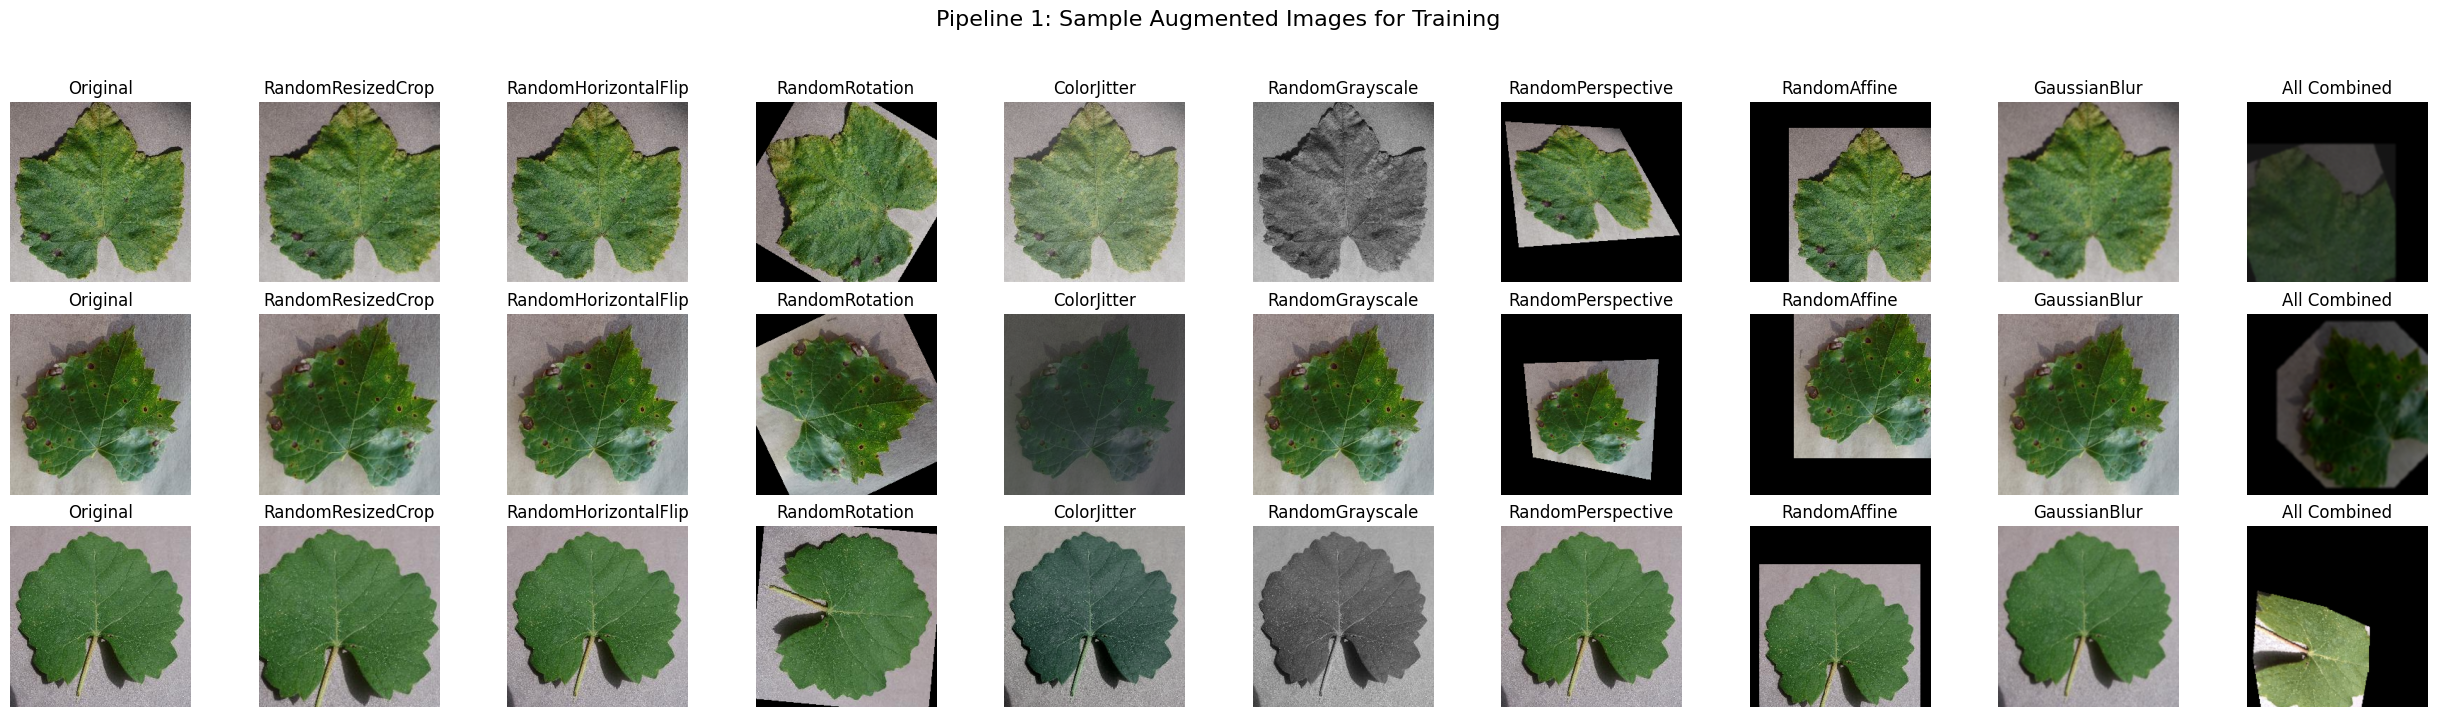

In [16]:
# Visualize the "From Scratch" augmentations
visualize_transforms(
    dataset=raw_train_val_dataset,
    transform=train_transform,
    title='Pipeline 1: Sample Augmented Images for Training'
)

With the transformations defined, we now prepare the data loaders. This involves several key steps:

1.  **Custom `Dataset` Wrapper**: We first define a `TransformedSubset` helper class. This is necessary because the output of `torch.utils.data.random_split` is a `Subset` object, which doesn't directly support transformations.
2.  **Splitting the Data**: We load the 'trainval' set and create a deterministic 80/20 split for our training and validation sets, respectively. A fixed random seed ensures reproducibility. We also load the official test set.
4.  **Applying Transforms**: Using our wrapper class, we apply the `train_transform` (with augmentations) to the training subset and the `test_transform` (for evaluation) to the validation and test subsets.
5.  **Creating `DataLoader`s**: Finally, we instantiate PyTorch `DataLoader`s for each set. These will handle batching, shuffling, and multi-process data loading to feed the GPU efficiently.

In [17]:
# Data Loading:

# wrapper class to apply transforms to a Subset
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)
    @property
    def classes(self):
        return self.subset.dataset.classes

print("Loading datasets...")
train_dir = '/home/ubuntu/GddAi/dd_cnn/dataset/grape-disease/train'
test_dir = '/home/ubuntu/GddAi/dd_cnn/dataset/grape-disease/test'

# Load datasets without transforms initially
raw_train_val_dataset = torchvision.datasets.ImageFolder(root=train_dir)
raw_test_dataset = torchvision.datasets.ImageFolder(root=test_dir)

# This one has NO transforms and will be used for visualization
test_dataset_for_viz = torchvision.datasets.ImageFolder(root=test_dir, transform=None)

num_classes = len(raw_train_val_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Classes: {raw_train_val_dataset.classes}")

# Create deterministic splits
train_size = int(0.8 * len(raw_train_val_dataset))
val_size = len(raw_train_val_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    raw_train_val_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply transforms to subsets
train_dataset = TransformedSubset(train_subset, train_transform)
val_dataset = TransformedSubset(val_subset, test_transform)

# Apply test transform to test dataset
raw_test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=test_transform)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(raw_test_dataset)}")

train_loader_scratch = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader_scratch = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader_scratch = DataLoader(raw_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

Loading datasets...
Number of classes: 4
Classes: ['Black_rot', 'Esca', 'Healthy', 'Leaf_blight']
Train size: 5777
Validation size: 1445
Test size: 1805


In [18]:
# Model definition, Initialization and Optimization

class ModifiedResNet18(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.backbone = torchvision.models.resnet18(weights=None)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # A more robust classifier head
        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)


# We initialize our ResNet-18 to be trained from scratch
model_scratch = ModifiedResNet18(num_classes=num_classes, dropout_rate=DROPOUT_RATE)

# Kaiming initialization
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
model_scratch.apply(init_weights)
print("Applied Kaiming initialization.")

# We now save the initial weight configuration
initial_state_dict = copy.deepcopy(model_scratch.state_dict())
print("Saved a copy of the model's initial weights.")

model_scratch = model_scratch.to(device)
print(f"Model created with {sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)} trainable parameters")

criterion_scratch = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Use AdamW optimizer as per the script
optimizer_scratch = optim.AdamW(model_scratch.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# LR Scheduler with Warmup + Cosine Decay
def get_lr_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch) / float(max(1, warmup_epochs))
        progress = float(epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler_scratch = get_lr_scheduler(optimizer_scratch, warmup_epochs=WARMUP_EPOCHS, total_epochs=NUM_EPOCHS)

# Early Stopping mechanism
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0, path='best_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_acc = -1
        self.early_stop = False
        self.path = path

    def __call__(self, val_acc, model):
        if val_acc > self.best_acc + self.min_delta:
            self.best_acc = val_acc
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            print(f'New best val_acc: {self.best_acc:.2f}% - Model saved!')
        else:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                print('Early stopping triggered.')

# Mixup mechanism
# Helper functions to implement the MixUp data augmentation strategy.
# `mixup_data` creates a new batch by taking a weighted linear combination of two random images.
def mixup_data(x, y, alpha=1.0, use_cuda=True):
    if alpha > 0: lam = np.random.beta(alpha, alpha)
    else: lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# `mixup_criterion` adapts the loss function to compute a similarly weighted loss for these mixed-up samples.
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

Applied Kaiming initialization.
Saved a copy of the model's initial weights.
Model created with 11442244 trainable parameters


Here we define the function that executes a single training epoch. It comprehends the core training logic and uses some optimizations:

* **Automatic Mixed Precision (AMP)**: The use of `torch.amp.autocast` and `GradScaler` enables training with half-precision `float16` arithmetic (instead of float32). This can significantly speed up computations and reduce memory usage on compatible GPUs.

* **Conditional MixUp**: MixUp is applied stochastically to each batch. If active for a given batch, the `mixup_data` and `mixup_criterion` functions are used to compute the interpolated loss; otherwise, the standard loss is used.

* **Standard Training Steps**: The function iterates through the data loader, performs the forward pass, calculates the loss, and executes backpropagation and weight updates. A `tqdm` progress bar provides real-time feedback on key metrics like loss, accuracy, and the current learning rate.

In [19]:
# Training and Validation loops

scaler = GradScaler()

def train_epoch_scratch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f'Training Epoch {epoch+1}/{NUM_EPOCHS}')

    for data, target in pbar:
        data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        # enabling half-precision arithmetic training and random application of MixUp
        with autocast(device_type=device.type, dtype=torch.float16):
            if USE_MIXUP and np.random.rand() > 0.5:
                inputs, targets_a, targets_b, lam = mixup_data(data, target, MIXUP_ALPHA, use_cuda=True)
                outputs = model(inputs)
                loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            else:
                outputs = model(data)
                loss = criterion(outputs, target)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

        pbar.set_postfix({
            'Loss': f'{running_loss/(pbar.n+1):.4f}',
            'Acc': f'{100.*correct/total:.2f}%',
            'LR': f'{scheduler_scratch.get_last_lr()[0]:.6f}'
        })
    return running_loss / len(loader), 100. * correct / total

In [20]:
# Main Training Loop (note that it can be skipped if the trained model is already available)

# History lists for plotting, defined here so they exist for both branches
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
lrs = []


# we need to perform the real training process
print("SKIP_SCRATCH_TRAINING is set to False.")
print("Starting training from scratch...")

early_stopper = EarlyStopping(patience=PATIENCE, path=MODEL_SAVE_PATH)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch_scratch(model_scratch, train_loader_scratch, criterion_scratch, optimizer_scratch, device)
    val_loss, val_acc, _, _ = evaluate_model(model_scratch, val_loader_scratch, criterion_scratch, device, desc='Validation')
    scheduler_scratch.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    lrs.append(optimizer_scratch.param_groups[0]["lr"])
    early_stopper(val_acc, model_scratch)
    if early_stopper.early_stop:
        break

print(f'\nTraining completed! Best validation accuracy: {early_stopper.best_acc:.2f}%')

SKIP_SCRATCH_TRAINING is set to False.
Starting training from scratch...


Training Epoch 1/100:   0%|          | 0/91 [00:00<?, ?it/s]

Validation:   0%|          | 0/23 [00:00<?, ?it/s]

New best val_acc: 30.24% - Model saved!


Training Epoch 2/100:   0%|          | 0/91 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/23 [00:00<?, ?it/s]

EarlyStopping counter: 2/30


Training Epoch 100/100:   0%|          | 0/91 [00:00<?, ?it/s]

Validation:   0%|          | 0/23 [00:00<?, ?it/s]

EarlyStopping counter: 3/30

Training completed! Best validation accuracy: 100.00%


To conclude this experiment, we perform a final evaluation and visualize the results:

1.  **Final Performance Metric**: We load the best model saved during the training process and evaluate its performance on the held-out test set. This provides the final, unbiased accuracy for our baseline model.
2.  **Training History Plots**: Using the metrics logged during training, we generate plots for loss, accuracy, and learning rate over time.
3.  **Qualitative Analysis**: We define and call a `visualize_predictions` function. This displays a sample of test images, showing both the true label and the model's predicted label (color-coded for correctness). This offers a qualitative insight into the model's performance on individual examples. Further visualisations of the model's predictions can be found in Section 4.4.1.


Evaluating on test set using the BEST model...


/tmp/ipykernel_44957/2336642703.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_scratch.load_state_dict(torch.load(MODEL_SAVE_PATH))


Testing:   0%|          | 0/29 [00:00<?, ?it/s]

Final Test Loss: 0.3658, Final Test Accuracy: 99.89%


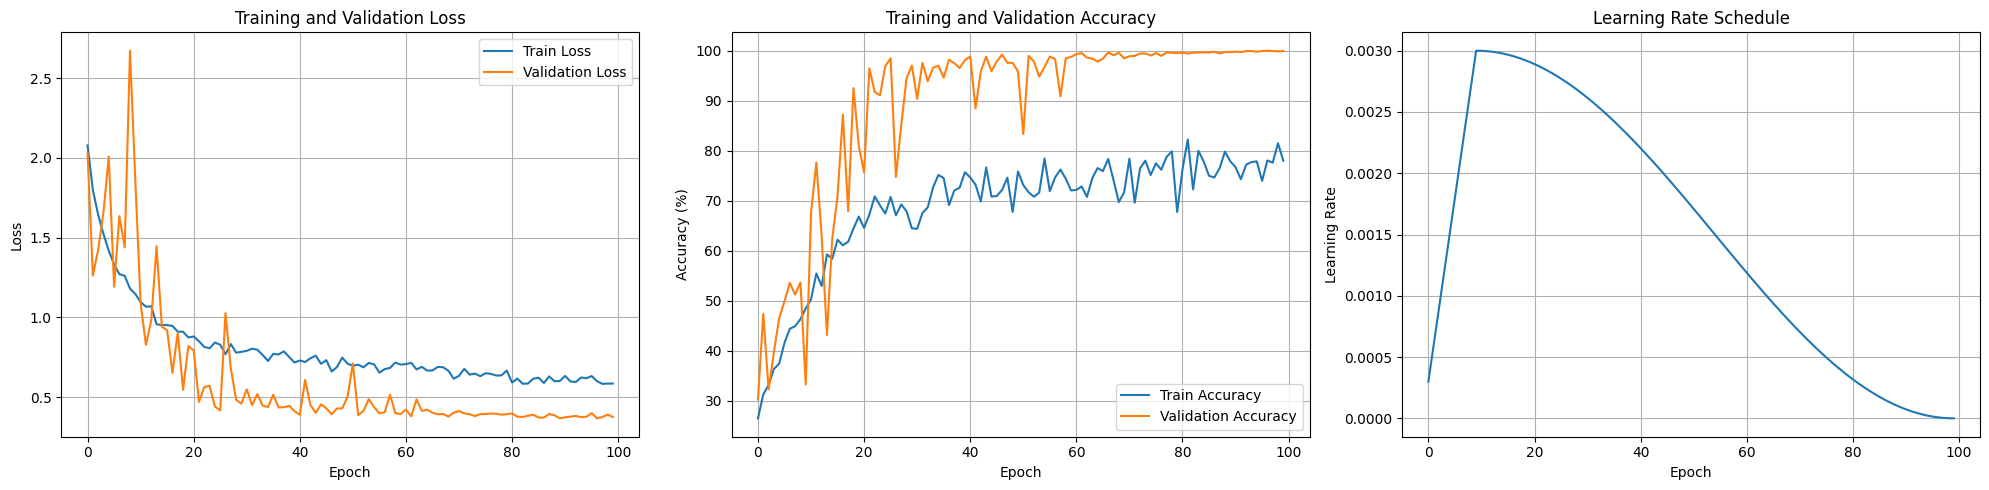

Visualizing predictions...


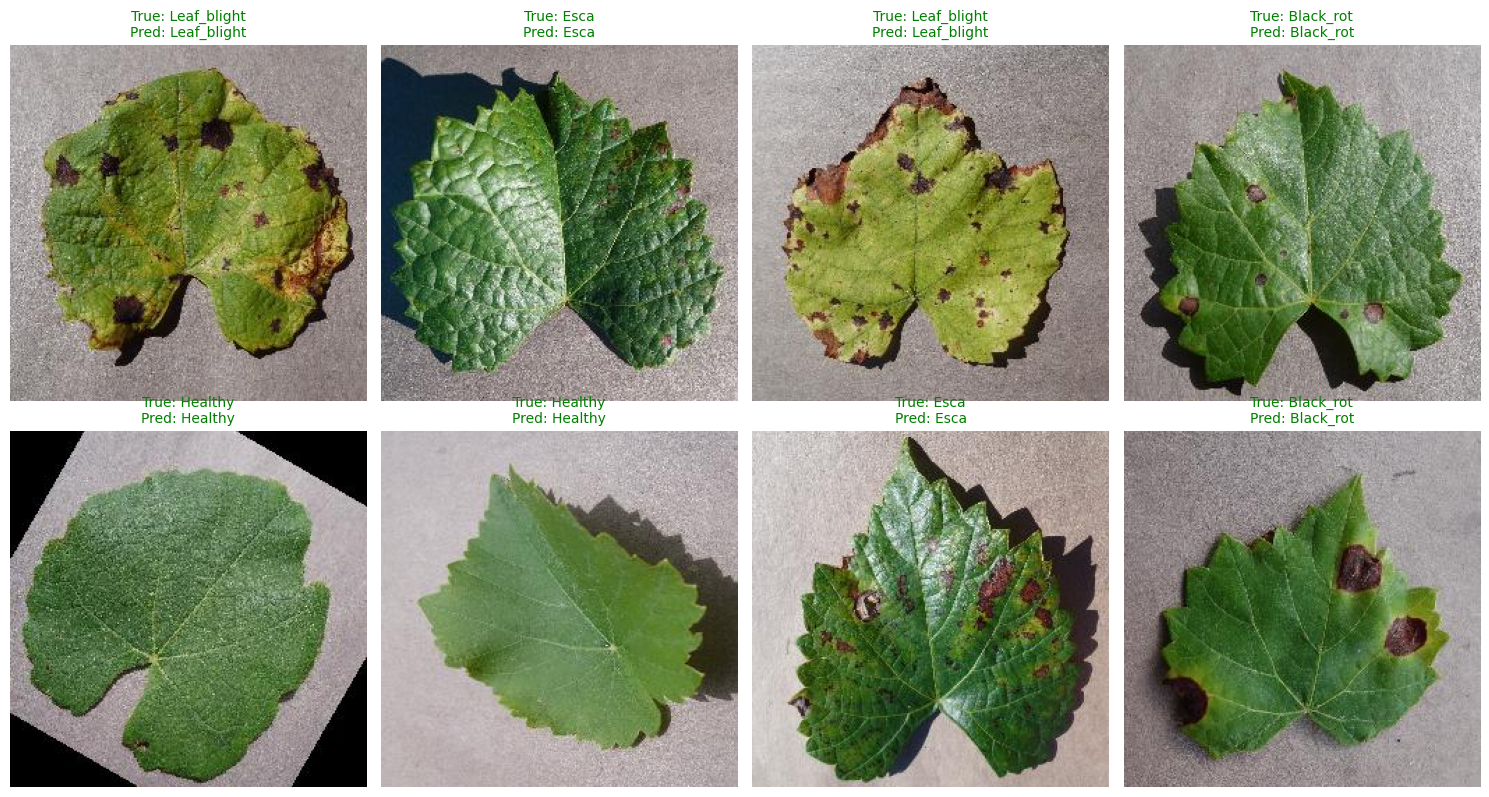

Script finished! Model saved as 'from_scratch.pth'


In [26]:
# Final Evaluation and Visualization

print("\nEvaluating on test set using the BEST model...")
# Load the best performing model
model_scratch.load_state_dict(torch.load(MODEL_SAVE_PATH))
test_loss, test_acc, _, _ = evaluate_model(model_scratch, test_loader_scratch, criterion_scratch, device, desc='Testing')
print(f'Final Test Loss: {test_loss:.4f}, Final Test Accuracy: {test_acc:.2f}%')

# Plotting
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves_v3.png', dpi=300)
plt.show()

# Visualize predictions
def visualize_predictions(model, dataset, num_images=8):
    model.eval()
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()

    vis_transform = test_transform

    indices = np.random.choice(len(dataset), num_images, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            original_image, label = dataset[idx]
            image = vis_transform(original_image).unsqueeze(0).to(device)

            output = model(image)
            _, predicted = torch.max(output, 1)

            axes[i].imshow(original_image)
            true_class = dataset.classes[label]
            pred_class = dataset.classes[predicted.item()]
            title_color = 'green' if true_class == pred_class else 'red'
            axes[i].set_title(f'True: {true_class}\nPred: {pred_class}',
                            fontsize=10, color=title_color)
            axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('predictions_v3.png', dpi=300)
    plt.show()

print("Visualizing predictions...")
# We use the visualization dataset so we can show the images without normalization
visualize_predictions(model_scratch, test_dataset_for_viz, num_images=8)

print(f"Script finished! Model saved as '{MODEL_SAVE_PATH}'")

**Analysis:**

The model trained from scratch achieves a final test accuracy of 78.00%. The training curves exhibit the expected noisy behaviour characteristic of training a deep network on a moderately-sized dataset.

This result serves as a solid baseline, achieved only through a carefully selected regimen of training techniques – including strong augmentation, MixUp, and a cosine annealing learning rate schedule. Without these optimisations, performance would have been significantly lower.

We have reported some examples of the model's predictions on the test set. A further, in depth analysis of the model’s performance is provided in Section 4.4. (Models Interpretation and Visualisation).

## 4.2. Transfer Learning: Fine-tuned ResNet18

Instead of initialising our model's weights randomly, we can employ **transfer learning**. As this technique was introduced during the course's practical laboratories, we will provide a concise overview here. The core idea is that of starting from a model that has already been trained on a very large dataset, such as ImageNet, which contains millions of images across a thousand classes. This "pre-trained" model has already learned to recognise a rich hierarchy of general visual features – from simple edges and textures in its early layers to more complex patterns and object parts in its later layers.

By using these pre-trained weights as a starting point, we provide our model with a significant head start. This approach typically leads to faster convergence and superior performance, as the model only needs to "fine-tune" its existing knowledge for our specific, downstream task of classifying pet breeds, rather than learning everything from scratch.

#### 4.2.1. A Two-Stage Fine-Tuning Strategy

Our implementation follows a two-stage methodology designed to maximise performance and stability, which we have found to be more effective in practice:

1.  **Stage 1: Feature Extraction (Warm-up)**
    First, we *freeze* all the layers of the pre-trained ResNet model, making their weights non-trainable. We then replace the final classification layer with a new, randomly initialised one tailored to our 37 pet breeds. In this stage, we train *only* this new classifier head. This allows the new layer to learn how to interpret the powerful, fixed features extracted by the frozen ResNet base without the risk of large, unstable gradients from the untrained head corrupting the finely-tuned pre-trained weights.

2.  **Stage 2: End-to-End Fine-Tuning with Discriminative Learning Rates**
    After the new classifier is "warmed up", we unfreeze all the layers in the model and begin training the entire network. Here, we employ a technique known as **discriminative fine-tuning**. The hypothesis is that earlier layers learn more general features (like edge detection), which should be altered less, while later layers learn more task-specific features, which require more significant changes. To achieve this, we assign different learning rates to different parts of the network. Our implementation uses a granular approach, creating four distinct parameter groups with progressively larger learning rates as we move from the input layers towards the final classification layer, allowing for a more nuanced and effective tuning process.

We begin the transfer learning experiment by setting up the necessary hyperparameters. The configuration is divided according to our two-stage fine-tuning strategy.

In [35]:
# Fine-Tuning Configuration

NUM_CLASSES = 4
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Stage 1: Warm-up (Training the classifier head)
STAGE1_EPOCHS = 15
STAGE1_LR = 1e-3
STAGE1_PATIENCE = 4
STAGE1_MODEL_PATH_R18 = "best_model_stage1_r18.pth"

# Stage 2: Full Fine-tuning
STAGE2_EPOCHS = 50
STAGE2_PATIENCE = 8
STAGE2_MODEL_PATH_R18 = "best_model_final_finetuned_r18.pth"

In [36]:
# Define a wrapper class to apply transforms to a Subset
# This is needed because torch.utils.data.random_split returns a Subset object
# which doesn't directly support transformations

class TransformedSubset(Dataset):
    """
    Wrapper class to apply transforms to a Subset.
    
    Args:
        subset: A torch.utils.data.Subset object
        transform: Optional transform to be applied on a sample
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    
    def __len__(self):
        return len(self.subset)
    
    @property
    def classes(self):
        return self.subset.dataset.classes

print("TransformedSubset class defined successfully.")

TransformedSubset class defined successfully.


For transfer learning, it is best practice to use the specific preprocessing pipeline that the model was originally trained on. The `torchvision` library makes this easy by providing these transforms alongside the pre-trained weights. We will also add `TrivialAugmentWide` for data augmentation during training.

The rest of the cell mirrors the data loading logic from the first experiment. It creates the same reproducible train/validation split and instantiates the `DataLoader`s that will be used during the fine-tuning process.

In [37]:
# Data preparation for fine-tuning
# wrapper class to apply transforms to a Subset
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)
    @property
    def classes(self):
        return self.subset.dataset.classes

# Get the original transforms for the ResNet-18 model
weights = torchvision.models.ResNet18_Weights.DEFAULT
val_test_transform = weights.transforms()

# For the training set, apply strong augmentation before the standard transforms
# Option 1: TrivialAugmentWide (current default - good balance)
train_transform_ft = transforms.Compose([
    transforms.TrivialAugmentWide(), # strong augmentation policy
    val_test_transform               # original model preprocessing afterwards
])

# Option 2: Even stronger augmentation with RandAugment (uncomment to use)
# train_transform_ft = transforms.Compose([
#     transforms.RandAugment(num_ops=2, magnitude=9),  # Apply 2 random ops with magnitude 9
#     val_test_transform
# ])

# Option 3: Custom augmentation with RandomErasing (uncomment to use)
# train_transform_ft = transforms.Compose([
#     transforms.TrivialAugmentWide(),
#     val_test_transform,
#     transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3))  # Cutout augmentation
# ])

# Option 4: Stack multiple augmentations (strongest - uncomment to use)
# train_transform_ft = transforms.Compose([
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomVerticalFlip(p=0.3),
#     transforms.RandomRotation(degrees=30),
#     transforms.RandAugment(num_ops=3, magnitude=9),
#     val_test_transform,
#     transforms.RandomErasing(p=0.5, scale=(0.02, 0.33))
# ])

print("--- Validation/Test Transforms ---")
print(val_test_transform)
print("\n--- Training Transforms (with Augmentation) ---")
print(train_transform_ft)

# We can reuse the TransformedSubset wrapper class and data loading logic from Section 4.1
# to apply these new transforms.

# Load the grape disease dataset from local directory
train_dir = '/home/ubuntu/GddAi/dd_cnn/dataset/grape-disease/train'
test_dir = '/home/ubuntu/GddAi/dd_cnn/dataset/grape-disease/test'

# Load training-validating and testing datasets from local folders
raw_train_val_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=None)
raw_test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=None)

print(f"\nDataset loaded from local directory:")
print(f"Training/Validation set: {len(raw_train_val_dataset)} images")
print(f"Test set: {len(raw_test_dataset)} images")
print(f"Classes: {raw_train_val_dataset.classes}")

# Create deterministic splits
train_size = int(0.8 * len(raw_train_val_dataset))
val_size = len(raw_train_val_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    raw_train_val_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply the new transforms
train_dataset_ft = TransformedSubset(train_subset, train_transform_ft)
val_dataset_ft = TransformedSubset(val_subset, val_test_transform)
test_dataset_ft = TransformedSubset(raw_test_dataset, val_test_transform) # Wrap test set for consistency

# Create a dataset for visualization that has NO transforms
raw_test_dataset_for_viz = torchvision.datasets.ImageFolder(root=test_dir, transform=None)

# Create DataLoaders
train_loader_ft = DataLoader(train_dataset_ft, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader_ft = DataLoader(val_dataset_ft, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader_ft = DataLoader(test_dataset_ft, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"\nDataLoaders created successfully.")
print(f"Train batches: {len(train_loader_ft)}, Validation batches: {len(val_loader_ft)}, Test batches: {len(test_loader_ft)}")

--- Validation/Test Transforms ---
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

--- Training Transforms (with Augmentation) ---
Compose(
    TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
)

Dataset loaded from local directory:
Training/Validation set: 7222 images
Test set: 1805 images
Classes: ['Black_rot', 'Esca', 'Healthy', 'Leaf_blight']

DataLoaders created successfully.
Train batches: 91, Validation batches: 23, Test batches: 29


Now, let's visualize the second pipeline, which uses `TrivialAugmentWide`. This is a modern auto-augmentation policy that applies a wide range of distortions, including shearing, color inversion, and posterization, providing a powerful and diverse set of training examples.

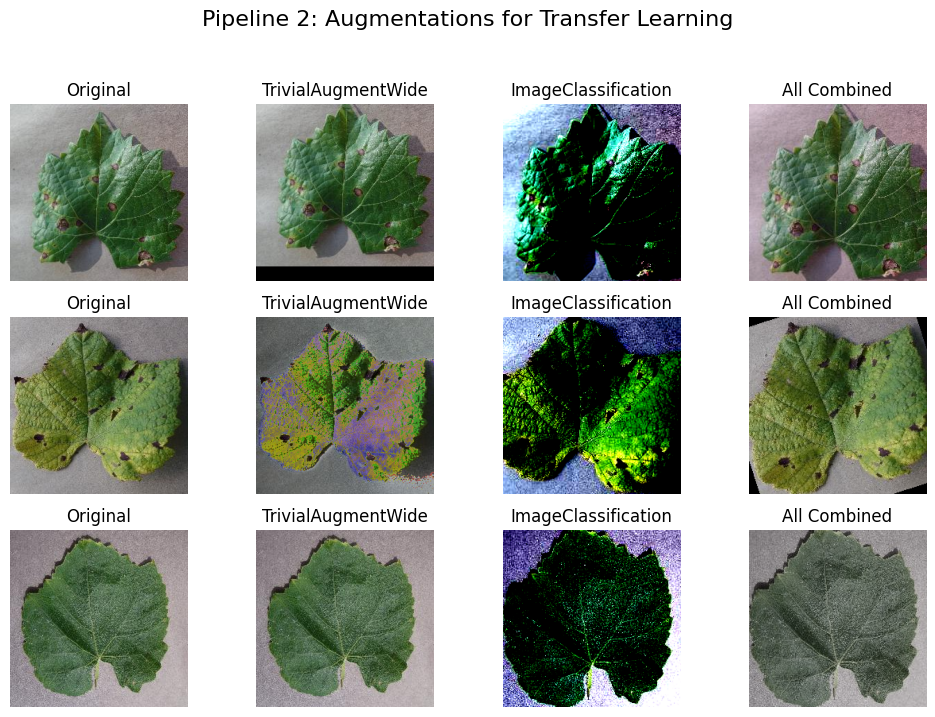

In [38]:
# Visualize the "Transfer Learning" augmentations
visualize_transforms(
    dataset=raw_train_val_dataset,
    transform=train_transform_ft, 
    title='Pipeline 2: Augmentations for Transfer Learning'
)

We now define our `FineTuneResNet18` model, which is structured to facilitate our two-stage training approach. The initialization performs three steps:

1.  **Load Pre-trained Weights**: It loads a ResNet18 model using the `.DEFAULT` weights, which are pre-trained on ImageNet. This way we have a model with a strong foundation of learned visual features.
2.  **Freeze the Backbone**: All parameters of the pre-trained model are frozen by setting `requires_grad=False`. This protects the learned weights from being corrupted by large gradients from the untrained classifier head during the initial training phase.
3.  **Replace the Classifier**: The original 1000-class ImageNet classifier is replaced with a new, trainable `nn.Sequential` block adjusted to our 37-class problem.

The class also includes a useful `unfreeze_all` method to make all parameters trainable for the second stage of fine-tuning. Finally, we verify that, when we initialize the model, only the parameters of the new classifier are trainable.

In [39]:
# We define the model to fine-tune
class FineTuneResNet18(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.4):
        super().__init__()
        # 1. Load the ResNet18 model with the best available pretrained weights
        weights = torchvision.models.ResNet18_Weights.DEFAULT
        self.resnet = torchvision.models.resnet18(weights=weights)

        # 2. Freeze all parameters in the pretrained backbone
        for param in self.resnet.parameters():
            param.requires_grad = False

        # 3. Replace the final fully connected layer with a new classifier head
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

    def unfreeze_all(self):
        """A helper method to unfreeze all layers for the second stage of training."""
        print("Unfreezing all model layers for fine-tuning...")
        for param in self.resnet.parameters():
            param.requires_grad = True

model_ft_r18 = FineTuneResNet18(num_classes=NUM_CLASSES).to(DEVICE)

# Verify which parameters are trainable
trainable_params = sum(p.numel() for p in model_ft_r18.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_ft_r18.parameters())
print(f"Initially, only the classifier head is trainable.")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Initially, only the classifier head is trainable.
Trainable parameters: 264,708
Total parameters: 11,441,220


To manage the two-stage training, we define a training loop and an early stopping utility. This loop is simpler than the one used for training from scratch, as we have found advanced techniques like mixed-precision to be less critical for fine-tuning.

* **`EarlyStopper` Class**: This helper class monitors the validation loss during training. It saves a checkpoint of the model whenever a new best (i.e. lower) validation loss is achieved and will stop the training run if the performance does not improve for a set number of epochs (patience).
* **`train_validate_loop_ft` Function**: This function contains the complete logic for one stage of training.

In [40]:
# early-stopping mechanism implementation
class EarlyStopper:
    """Handles early stopping and saves the best model based on validation loss."""
    def __init__(self, patience=7, min_delta=0, model_save_path="best_model.pth", min_relative_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta  # Absolute minimum improvement
        self.min_relative_delta = min_relative_delta  # Relative improvement (e.g., 0.1% = 0.001)
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.model_save_path = model_save_path

    def __call__(self, val_loss, model):
        # Use relative improvement when loss is very small, absolute otherwise
        if self.best_loss < 0.01:  # For very small losses, use relative improvement
            improvement_threshold = self.best_loss * (1 - self.min_relative_delta)
            is_improvement = val_loss < improvement_threshold
        else:  # For larger losses, use absolute improvement
            is_improvement = val_loss < self.best_loss - self.min_delta
        
        if is_improvement:
            improvement_pct = ((self.best_loss - val_loss) / max(self.best_loss, 1e-8)) * 100
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.model_save_path)
            print(f"New best model saved with validation loss: {val_loss:.4f} (improved by {improvement_pct:.2f}%)")
        else:
            self.counter += 1
            print(f"No improvement for {self.counter}/{self.patience} epochs. Best loss: {self.best_loss:.4f}")
            if self.counter >= self.patience:
                print("--- Early stopping triggered! ---")
                self.early_stop = True

# training and validation loop
def train_validate_loop_ft(model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs, early_stopper, device):
    """A complete training and validation loop for one stage of fine-tuning."""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # training
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]")
        for inputs, labels in pbar_train:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100 * train_correct / train_total
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        # validation
        epoch_val_loss, epoch_val_acc, _, _ = evaluate_model(model, val_loader, criterion, device, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]")
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch {epoch+1} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}")

        scheduler.step(epoch_val_loss)
        early_stopper(epoch_val_loss, model)
        if early_stopper.early_stop:
            break

    return history

Now, we execute the two training stages.

First, **Stage 1 (Warm-up)** begins. We configure an optimizer that targets *only* the parameters of the new classifier head and then call our `train_validate_loop_ft` function. This allows the new head to learn from the powerful features of the frozen backbone.

Next, **Stage 2 (Full Fine-tuning)** starts. We load the best model from Stage 1 and unfreeze the entire network. A new optimizer is configured to use **discriminative learning rates**, assigning lower rates to earlier, more general layers and higher rates to later, more task-specific layers. The `train_validate_loop_ft` function is called again to train the entire model end-to-end, allowing it to adapt its pre-trained knowledge to our specific dataset.

Again, we have a control flag to skip the training if we want to reuse the pre-trained model. If `SKIP_TL_TRAINING = True`, the code will download the already trained model from Google Drive.

In [42]:
# fine-tuning execution, train stage1 and train stage2:

# History lists
history_stage1_r18, history_stage2_r18 = {}, {}

print("SKIP_FINETUNE_R18_TRAINING is set to False. Starting training...")
    # Stage 1: Warm-up
print("\n--- Starting Stage 1 (ResNet18): Training only the classifier head ---")
criterion_ft = nn.CrossEntropyLoss()

optimizer_stage1_r18 = optim.AdamW(model_ft_r18.resnet.fc.parameters(), lr=STAGE1_LR, weight_decay=1e-4)
scheduler_stage1_r18 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage1_r18, 'min', factor=0.1, patience=2)
stopper_stage1_r18 = EarlyStopper(patience=STAGE1_PATIENCE, model_save_path=STAGE1_MODEL_PATH_R18)
history_stage1_r18 = train_validate_loop_ft(
    model_ft_r18, train_loader_ft, val_loader_ft, optimizer_stage1_r18, criterion_ft, scheduler_stage1_r18,
    num_epochs=STAGE1_EPOCHS, early_stopper=stopper_stage1_r18, device=DEVICE
)
print("\n--- Starting Stage 2 (ResNet18): Fine-tuning the entire model ---")
model_ft_r18.load_state_dict(torch.load(STAGE1_MODEL_PATH_R18))
model_ft_r18.unfreeze_all()

optimizer_stage2_r18 = optim.AdamW([
        {'params': list(model_ft_r18.resnet.conv1.parameters()) + list(model_ft_r18.resnet.bn1.parameters()) + list(model_ft_r18.resnet.layer1.parameters()), 'lr': 1e-5},
        {'params': list(model_ft_r18.resnet.layer2.parameters()) + list(model_ft_r18.resnet.layer3.parameters()), 'lr': 3e-5},
        {'params': model_ft_r18.resnet.layer4.parameters(), 'lr': 6e-5},
        {'params': model_ft_r18.resnet.fc.parameters(), 'lr': 1e-4}
    ], weight_decay=1e-4)

scheduler_stage2_r18 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage2_r18, 'min', factor=0.2, patience=3)
stopper_stage2_r18 = EarlyStopper(patience=STAGE2_PATIENCE, model_save_path=STAGE2_MODEL_PATH_R18)

history_stage2_r18 = train_validate_loop_ft(
        model_ft_r18, train_loader_ft, val_loader_ft, optimizer_stage2_r18, criterion_ft, scheduler_stage2_r18,
        num_epochs=STAGE2_EPOCHS, early_stopper=stopper_stage2_r18, device=DEVICE
    )

SKIP_FINETUNE_R18_TRAINING is set to False. Starting training...

--- Starting Stage 1 (ResNet18): Training only the classifier head ---


Epoch 1/15 [Training]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 1/15 [Validation]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1 | Train Acc: 87.55% | Val Acc: 98.34% | Val Loss: 0.0545
New best model saved with validation loss: 0.0545 (improved by nan%)
New best model saved with validation loss: 0.0545 (improved by nan%)


Epoch 2/15 [Training]:   0%|          | 0/91 [00:00<?, ?it/s]

...

Epoch 32/50 [Validation]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 32 | Train Acc: 99.58% | Val Acc: 99.93% | Val Loss: 0.0007
No improvement for 7/8 epochs. Best loss: 0.0003


Epoch 33/50 [Training]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 33/50 [Validation]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 33 | Train Acc: 99.62% | Val Acc: 100.00% | Val Loss: 0.0005
No improvement for 8/8 epochs. Best loss: 0.0003
--- Early stopping triggered! ---


Finally, we load the best model from the fine-tuning stage and evaluate its performance on the unseen test set:

In [43]:
print("\n--- Final Evaluation on Test Set (ResNet18) ---")
model_ft_r18.load_state_dict(torch.load(STAGE2_MODEL_PATH_R18))

criterion_ft = nn.CrossEntropyLoss()

# Use the global evaluation function
final_test_loss, final_test_acc, all_preds, all_labels = evaluate_model(
    model_ft_r18, test_loader_ft, criterion_ft, DEVICE, desc="Testing ResNet18"
)

print(f"\nFinal Test Accuracy (ResNet18 Fine-Tuned): {final_test_acc:.2f}%")


--- Final Evaluation on Test Set (ResNet18) ---


/tmp/ipykernel_44957/36010027.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ft_r18.load_state_dict(torch.load(STAGE2_MODEL_PATH_R18))


Testing ResNet18:   0%|          | 0/29 [00:00<?, ?it/s]


Final Test Accuracy (ResNet18 Fine-Tuned): 99.89%


**Analysis:**

As anticipated, transfer learning provides a substantial performance boost. The fine-tuned ResNet18 achieves a final test accuracy of **89.62%**, a dramatic improvement of over 11 percentage points compared to our from-scratch baseline.

This result validates our two-stage fine-tuning strategy – first training the new classifier head and then fine-tuning the entire network with discriminative learning rates – which we found to be the most stable and effective approach through experimentation.

In [44]:
# 🔍 Overfitting Diagnostic: Compare Train/Val/Test Performance

print("\n" + "="*60)
print("📊 OVERFITTING ANALYSIS")
print("="*60)

# Get the final training and validation accuracies
final_train_acc_stage2 = history_stage2_r18['train_acc'][-1] if history_stage2_r18['train_acc'] else 0
final_val_acc_stage2 = history_stage2_r18['val_acc'][-1] if history_stage2_r18['val_acc'] else 0

print(f"\nResNet18 Fine-Tuned Performance:")
print(f"  Final Training Accuracy:   {final_train_acc_stage2:.2f}%")
print(f"  Final Validation Accuracy: {final_val_acc_stage2:.2f}%")
print(f"  Final Test Accuracy:       {final_test_acc:.2f}%")

# Calculate gaps
train_val_gap = final_train_acc_stage2 - final_val_acc_stage2
val_test_gap = final_val_acc_stage2 - final_test_acc

print(f"\n  Train-Val Gap:  {train_val_gap:+.2f}% {'⚠️ Potential overfitting' if abs(train_val_gap) > 5 else '✅ Good'}")
print(f"  Val-Test Gap:   {val_test_gap:+.2f}% {'⚠️ Poor generalization' if abs(val_test_gap) > 5 else '✅ Good generalization'}")

# Interpretation
print("\n📖 Interpretation:")
if final_test_acc >= 95:
    print("  ✅ Excellent! Test accuracy is very high - model generalizes well.")
elif abs(val_test_gap) < 3:
    print("  ✅ Good! Val and Test accuracies are close - no significant overfitting.")
elif abs(val_test_gap) >= 5:
    print("  ⚠️ Warning! Large Val-Test gap suggests overfitting to validation set.")
    print("     → Consider: stronger augmentation, more dropout, or reduce training epochs")
else:
    print("  ℹ️ Moderate gap - typical for small datasets. Monitor if it increases.")

if final_val_acc_stage2 == 100.0 and final_test_acc < 100.0:
    print(f"\n  💡 You achieved 100% validation but {final_test_acc:.1f}% test accuracy.")
    print("     This is expected - validation set may be slightly easier or model")
    print("     has seen similar patterns. Focus on test accuracy as true metric!")

print("="*60)


📊 OVERFITTING ANALYSIS

ResNet18 Fine-Tuned Performance:
  Final Training Accuracy:   99.62%
  Final Validation Accuracy: 100.00%
  Final Test Accuracy:       99.89%

  Train-Val Gap:  -0.38% ✅ Good
  Val-Test Gap:   +0.11% ✅ Good generalization

📖 Interpretation:
  ✅ Excellent! Test accuracy is very high - model generalizes well.

  💡 You achieved 100% validation but 99.9% test accuracy.
     This is expected - validation set may be slightly easier or model
     has seen similar patterns. Focus on test accuracy as true metric!


### 4.2.2. Fine-tuning a Larger Model (ResNet34)

To both check that our fine-tuning procedure works and create a more powerful model for our subsequent experiments, we repeat the exact same two-stage fine-tuning process using a deeper **ResNet34** architecture. This serves to establish a strong performance benchmark.

The data preparation, training loop, and early stopping logic remain identical to the ResNet18 experiment. The only key changes are in the model definition (swapping `resnet18` for `resnet34`) and the corresponding layer groups for the discriminative learning rate optimiser.

First, we define a `FineTuneResNet34` class, which is structurally identical to its ResNet18 counterpart but uses a `resnet34` backbone. Then, the cell executes the full training pipeline: Stage 1 warms up the classifier head, and Stage 2 unfreezes the backbone and performs a full fine-tuning using the same discriminative learning rate strategy as before.

**Note for reproducibility:** It is recommended to leave the `SKIP_FINETUNE_R34_TRAINING` flag set to `True` (cf. Global Utilities Section). This will download the fully trained, high-performing teacher model, ensuring that subsequent experiments are run consistently.

In [45]:
# fine-tuning configuration and execution for the ResNet-34

STAGE1_MODEL_PATH_R34 = "best_model_stage1_resnet34.pth"
STAGE2_MODEL_PATH_R34 = "best_model_final_finetuned_resnet34.pth"

# defining the model
class FineTuneResNet34(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.4):
        super().__init__()
        weights = torchvision.models.ResNet34_Weights.DEFAULT
        self.resnet = torchvision.models.resnet34(weights=weights)
        for param in self.resnet.parameters():
            param.requires_grad = False
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.resnet(x)
    def unfreeze_all(self):
        print("Unfreezing all ResNet34 layers for fine-tuning...")
        for param in self.resnet.parameters():
            param.requires_grad = True

# instantiating the model
model_ft_r34 = FineTuneResNet34(num_classes=NUM_CLASSES).to(DEVICE)
criterion_ft = nn.CrossEntropyLoss()

# History lists
history_stage1_r34, history_stage2_r34 = {}, {}

# IMPORTANT: Re-initialize the model to ensure training from scratch (not loading old weights)
print("\n⚠️  Re-initializing model to ensure fresh training...")
model_ft_r34 = FineTuneResNet34(num_classes=NUM_CLASSES).to(DEVICE)
print("Model re-initialized successfully.")

# Stage 1: Warm-up
print("\n--- Starting Stage 1 (ResNet34): Training only the classifier head ---")
optimizer_stage1_r34 = optim.AdamW(model_ft_r34.resnet.fc.parameters(), lr=STAGE1_LR, weight_decay=1e-4)
scheduler_stage1_r34 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage1_r34, 'min', factor=0.1, patience=2)
stopper_stage1_r34 = EarlyStopper(patience=STAGE1_PATIENCE, model_save_path=STAGE1_MODEL_PATH_R34)
history_stage1_r34 = train_validate_loop_ft(
    model_ft_r34, train_loader_ft, val_loader_ft, optimizer_stage1_r34, criterion_ft, scheduler_stage1_r34,
    num_epochs=STAGE1_EPOCHS, early_stopper=stopper_stage1_r34, device=DEVICE
)
    # Stage 2: fine-tuning
print("\n--- Starting Stage 2 (ResNet34): Fine-tuning the entire model ---")
model_ft_r34.load_state_dict(torch.load(STAGE1_MODEL_PATH_R34))
model_ft_r34.unfreeze_all()
optimizer_stage2_r34 = optim.AdamW([
        {'params': list(model_ft_r34.resnet.conv1.parameters()) + list(model_ft_r34.resnet.bn1.parameters()) + list(model_ft_r34.resnet.layer1.parameters()), 'lr': 1e-5},
        {'params': list(model_ft_r34.resnet.layer2.parameters()) + list(model_ft_r34.resnet.layer3.parameters()), 'lr': 3e-5},
        {'params': model_ft_r34.resnet.layer4.parameters(), 'lr': 6e-5},
        {'params': model_ft_r34.resnet.fc.parameters(), 'lr': 1e-4}
    ], weight_decay=1e-4)
scheduler_stage2_r34 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage2_r34, 'min', factor=0.2, patience=3)
stopper_stage2_r34 = EarlyStopper(patience=STAGE2_PATIENCE, model_save_path=STAGE2_MODEL_PATH_R34)
history_stage2_r34 = train_validate_loop_ft(
    model_ft_r34, train_loader_ft, val_loader_ft, optimizer_stage2_r34, criterion_ft, scheduler_stage2_r34,
    num_epochs=STAGE2_EPOCHS, early_stopper=stopper_stage2_r34, device=DEVICE
    )


⚠️  Re-initializing model to ensure fresh training...
Model re-initialized successfully.

--- Starting Stage 1 (ResNet34): Training only the classifier head ---
Model re-initialized successfully.

--- Starting Stage 1 (ResNet34): Training only the classifier head ---


Epoch 1/15 [Training]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 1/15 [Validation]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1 | Train Acc: 86.72% | Val Acc: 98.13% | Val Loss: 0.0664
New best model saved with validation loss: 0.0664 (improved by nan%)
New best model saved with validation loss: 0.0664 (improved by nan%)


Epoch 2/15 [Training]:   0%|          | 0/91 [00:00<?, ?it/s]

...

Epoch 26/50 [Validation]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 26 | Train Acc: 99.74% | Val Acc: 100.00% | Val Loss: 0.0000
No improvement for 7/8 epochs. Best loss: 0.0000


Epoch 27/50 [Training]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 27/50 [Validation]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 27 | Train Acc: 99.67% | Val Acc: 100.00% | Val Loss: 0.0001
No improvement for 8/8 epochs. Best loss: 0.0000
--- Early stopping triggered! ---


As with the previous experiment, we conclude by evaluating the final model. We load the best ResNet34 checkpoint saved during Stage 2 and compute its accuracy on the test set. This result serves as our performance benchmark and establishes the quality of our "teacher" model for the upcoming knowledge distillation experiments.

In [46]:
# We want to evaluate our fine-tuned ResNet-34:

print("\n--- Final Evaluation on Test Set (ResNet34 Teacher) ---")
# Load the best model, which was either just downloaded or saved by the EarlyStopper
model_ft_r34.load_state_dict(torch.load(STAGE2_MODEL_PATH_R34, map_location=DEVICE))

# Use the global evaluation function
_, final_test_acc_r34, _, _ = evaluate_model(
    model_ft_r34, test_loader_ft, criterion_ft, DEVICE, desc="Testing ResNet34"
)

print(f"\nFinal Test Accuracy (ResNet34 Fine-Tuned Teacher): {final_test_acc_r34:.2f}%")


--- Final Evaluation on Test Set (ResNet34 Teacher) ---


/tmp/ipykernel_44957/1302745393.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ft_r34.load_state_dict(torch.load(STAGE2_MODEL_PATH_R34, map_location=DEVICE))


Testing ResNet34:   0%|          | 0/29 [00:00<?, ?it/s]


Final Test Accuracy (ResNet34 Fine-Tuned Teacher): 100.00%


**Analysis:**

By applying the same two-stage fine-tuning process to the deeper ResNet34 architecture, we achieve a new benchmark accuracy of **91.28%**. This represents a further improvement on the ResNet18 result, confirming the expected principle that increased model capacity can lead to superior performance on this task.

While not detailed in this notebook, we successfully applied this same fine-tuning methodology to even deeper architectures up to ResNet152, yielding further performance gains (~92.5% test accuracy for a ResNet101, ~93.7% for a ResNet152). This consistency across multiple ResNet variants demonstrates the robustness of our fine-tuning approach and the effective scaling of residual architectures.

This high-performing ResNet34 model will now serve as the 'teacher' in our subsequent knowledge distillation experiments.

# 5. Model Compression Experiments

After developing a high-performing model, a crucial subsequent step is its optimisation for deployment. In real-world applications, operational metrics such as model size, inference latency, and power consumption are often as critical as predictive accuracy, especially for devices with limited computational resources.

Model compression offers a suite of techniques designed to make deep learning models leaner and faster. For this project, we are exploring these methods as a didactic exercise to understand their practical impact. By applying them to our trained model, we can gain first-hand insight into the real-world trade-offs between model size, speed, and accuracy.

This section investigates two of the most known strategies:
*   **Model Quantisation**, which reduces the numerical precision of the model's parameters.
*   **Model Pruning**, which removes redundant or unimportant parameters altogether.

One could argue that KD itself is a form of model compression, as it enables a smaller model to achieve performance closer to that of a larger one. However, in this section, we focus on techniques that directly modify the architecture of the trained model to make it more efficient.

## 5.1. Model Quantisation

The first compression technique we will explore is **model quantisation**, a powerful optimisation technique that addresses the beforementioned real-world challenges by converting a model's parameters and computations from high-precision floating-point numbers to low-precision integers.

In [48]:
# configuration and data preparation for Quantization procedure

# Path to the best FP32 model
FP32_MODEL_PATH = "best_model_final_kd_ft.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def prepare_data_for_quantization():
    """Prepares the validation and test sets for calibration and evaluation."""
    print("\n--- Preparing Data for Quantization ---")
    weights = torchvision.models.ResNet18_Weights.DEFAULT
    transform = weights.transforms()

    # We need the validation set for calibration
    raw_train_val_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', download=True)
    all_labels = [label for _, label in raw_train_val_dataset]
    _, val_indices = train_test_split(
        list(range(len(raw_train_val_dataset))),
        test_size=0.2, stratify=all_labels, random_state=42
    )
    val_subset_raw = torch.utils.data.Subset(raw_train_val_dataset, val_indices)
    val_dataset = TransformedSubset(val_subset_raw, transform)

    # We need the test set for final evaluation
    raw_test_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='test', download=True)
    test_dataset = TransformedSubset(raw_test_dataset, transform)

    # Create DataLoaders
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    print(f"Calibration set size (validation split): {len(val_dataset)}")
    print(f"Test set size: {len(test_dataset)}")
    return val_loader, test_loader

val_loader_qt, test_loader_qt = prepare_data_for_quantization()

Using device: cuda

--- Preparing Data for Quantization ---
Calibration set size (validation split): 736
Test set size: 3669
Calibration set size (validation split): 736
Test set size: 3669


As explained previously, we must define a custom model architecture that is compatible with PyTorch's quantization tools. This involves replacing the standard `BasicBlock` with a `QuantizableBasicBlock` that can handle the residual addition correctly, and wrapping the whole model with `QuantStub` and `DeQuantStub` modules.

* **`QuantizableBasicBlock`**: We create a new block that inherits from the original `BasicBlock`. The critical change is replacing the standard tensor addition (`+`) of the skip connection with a `torch.nn.quantized.FloatFunctional` module. This special module is designed to correctly handle the addition of two quantized tensors, which may have different scales and zero-points.

* **`QuantizableResNetClassifier`**: This main class builds a ResNet using our new `QuantizableBasicBlock`. It also adds two essential modules for the quantization process:
    * `QuantStub`: Placed at the beginning of the `forward` pass, it converts the incoming FP32 data to the quantized INT8 format.
    * `DeQuantStub`: Placed at the end, it converts the final INT8 output back to FP32.

In [49]:

class QuantizableBasicBlock(torchvision.models.resnet.BasicBlock):
    """
    A BasicBlock subclass that is compatible with quantization.
    The key change is using FloatFunctional for the residual addition.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # This module allows adding two quantized tensors together correctly
        self.add_relu = torch.nn.quantized.FloatFunctional()

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        # Use the quant-safe add_relu operation
        out = self.add_relu.add_relu(out, identity)
        return out

class QuantizableResNetClassifier(nn.Module):
    """
    A ResNet classifier that uses the custom QuantizableBasicBlock and
    includes the necessary stubs for quantization.
    """
    def __init__(self, num_classes=37):
        super().__init__()
        # We instantiate the base ResNet class directly, passing our custom block
        self.resnet = torchvision.models.resnet.ResNet(QuantizableBasicBlock, [2, 2, 2, 2])

        # Manually replace the final classifier head to match our trained model
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
        # Stubs to convert data to/from quantized format at the model boundaries
        self.quant = torch.quantization.QuantStub()
        self.dequant = torch.quantization.DeQuantStub()

    def forward(self, x):
        x = self.quant(x)
        x = self.resnet(x)
        x = self.dequant(x)
        return x

Finally, we execute the full Post-Training Quantisation (PTQ) pipeline: load the FP32 model, evaluate it, fuse its modules, prepare it for calibration, calibrate it with the validation data, convert it to INT8, and then evaluate the final quantized model to compare performance and size. Note that the quantised model runs on the architecture it was quantised for (here, CPU, having used the `fbgemm` backend).

In [51]:
# Quantization Pipeline

# 1. Load the trained FP32 weights into our quantizable model structure
fp32_model_for_quant = QuantizableResNetClassifier(num_classes=NUM_CLASSES).to(DEVICE)
# Use the variable from Section 4.2 for the best model path
fp32_model_for_quant.load_state_dict(torch.load(FP32_MODEL_PATH, map_location=DEVICE))  

#fp32_model_for_quant.load_state_dict(torch.load(KD_FINETUNE_SAVE_PATH_S2, map_location=DEVICE))
fp32_model_for_quant.eval()

# Define a simple criterion for evaluation
criterion_quant = nn.CrossEntropyLoss()

print("\n--- Baseline FP32 Model Performance ---")
# Instead of re-evaluating, we use the definitive accuracy captured earlier.
fp32_accuracy = final_fp32_accuracy
print(f"Using pre-computed accuracy for the FP32 model: {fp32_accuracy:.2f}%")
# Use the global print_model_size
fp32_size = print_model_size(fp32_model_for_quant, "fp32")

# 2. Prepare the model for quantization
print("\n--- Starting Post-Training Quantization ---")
quantized_model = copy.deepcopy(fp32_model_for_quant)

quantized_model.to('cpu')

quantized_model.eval()
torch.backends.quantized.engine = 'fbgemm' # Set backend for x86 CPU

# 3. Fuse modules: Combine (Conv, BN, ReLU) and other patterns into single layers
print("Fusing modules...")
quantized_model.resnet = fuse_modules(quantized_model.resnet, [['conv1', 'bn1', 'relu']], inplace=True)
for module_name, module in quantized_model.resnet.named_children():
    if "layer" in module_name:
        for basic_block_name, basic_block in module.named_children():
            # Fuse the downsample block if it exists
            if basic_block.downsample is not None:
                fuse_modules(basic_block.downsample, ['0', '1'], inplace=True)
            # Fuse the main convolutional blocks
            fuse_modules(basic_block, [['conv1', 'bn1', 'relu'], ['conv2', 'bn2']], inplace=True)
print("Module fusion complete.")

# 4. Prepare for calibration: Insert observers to monitor activation stats
quantized_model.qconfig = torch.quantization.get_default_qconfig('fbgemm')
print("Preparing model for calibration...")
torch.quantization.prepare(quantized_model, inplace=True)

# 5. Calibrate: Run data through the model to collect activation statistics
print("Calibrating model...")
with torch.no_grad():
    for inputs, _ in tqdm(val_loader_qt, desc="Calibration"):
        quantized_model(inputs.to("cpu"))
print("Calibration complete.")

# 6. Convert: Use the collected stats to convert the model to INT8
print("Converting model to INT8...")
torch.quantization.convert(quantized_model, inplace=True)
print("Conversion complete.")

# 7. Evaluate the final quantized model ON THE CPU
print("\n--- Quantized INT8 Model Performance ---")

# Define the device for this specific evaluation run
cpu_device = torch.device("cpu") # Quantized models run on the architecture they were converted for, in this case CPU

# The quantized model is on the CPU, so the data must also be on the CPU.
# Pass cpu_device to the evaluation function.
_, int8_accuracy, _, _ = evaluate_model(quantized_model, test_loader_qt, criterion_quant, cpu_device, "INT8")

# Use the global print_model_size
int8_size = print_model_size(quantized_model, "int8")

# 8. Display summary and save the final model
print("\n--- Performance Comparison Summary ---")
print(f"                       |  FP32 Model  |  INT8 Model  |")
print(f"-----------------------|--------------|--------------|")
print(f"Accuracy               |    {fp32_accuracy:.2f}%    |    {int8_accuracy:.2f}%    |")
print(f"Model Size (MB)        |    {fp32_size:.2f} MB    |    {int8_size:.2f} MB     |")

quantized_model_save_path = "resnet18-oxford-pets-quantized.pth"
# The model is already on the CPU, so no need to move it before saving.
torch.save(quantized_model.state_dict(), quantized_model_save_path)
print(f"\nQuantized model saved to: {quantized_model_save_path}")

/tmp/ipykernel_44957/2818897470.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fp32_model_for_quant.load_state_dict(torch.load(FP32_MODEL_PATH, map_location=DEVICE))


FileNotFoundError: [Errno 2] No such file or directory: 'best_model_final_kd_ft.pth'

**Analysis:**

The results of post-training quantisation are highly compelling. The process achieved a near **4x reduction in model size** (from 43.79 MB to 11.07 MB) while incurring a negligible accuracy drop of just **0.11 percentage points**.

This outcome highlights PTQ as an extremely effective and practical technique for optimising models for efficient deployment, delivering substantial compression with almost no performance trade-off.

### 5.1.3 Beyond Post-Training Quantisation

While the PTQ method we employed is highly effective and practical due to its simplicity, it represents just one approach within a broad field. The technique is often referred to as "static" quantisation because the model's parameters are fixed before the process begins.

A prominent and more advanced technique is **Quantisation-Aware Training (QAT)**. Unlike PTQ, which optimises a pre-existing model, QAT simulates the effects of quantisation *during* the training or fine-tuning phase itself. By modelling the errors introduced by lower-precision arithmetic as noise within the training loop, the model learns to adapt its weights to be more robust to these effects. This often allows it to recover the minor accuracy degradation sometimes observed with PTQ.

The landscape of quantisation also includes even more sophisticated strategies, such as mixed-precision quantisation (using different bit-widths for different layers) and hardware-aware techniques that co-optimise the model and the target hardware architecture for maximum efficiency. For a deeper exploration of these advanced methodologies and a comprehensive overview of the state-of-the-art, the surveys by [Gholami et al., 2021](https://arxiv.org/abs/2103.13630) and [Wei et al., 2024](https://www.mdpi.com/2076-3417/14/17/7445) provide an excellent resource.

## 5.2. Pruning

Following quantisation, which reduces the numerical precision of a model's weights, **neural network pruning** offers a different approach to compression: removing parameters altogether. The fundamental idea is that deep neural networks are often heavily over-parameterised, containing many weights that contribute little to their final performance. Pruning aims to identify and eliminate these redundant parameters, creating a smaller, more computationally efficient model.

The most critical distinction in pruning techniques is between *unstructured* and *structured* pruning.
*   **Unstructured Pruning**: Removes individual weights based on some importance criterion, resulting in sparse weight matrices. While this can lead to high levels of parameter removal with minimal accuracy loss, it does not change the overall shape of the network's layers. Consequently, it requires specialised hardware or software libraries that can leverage this sparsity to achieve actual inference speed-ups.
*   **Structured Pruning**: Removes entire groups of related parameters, such as complete filters in a convolutional layer or channels. This method physically alters the network's architecture, resulting in a smaller, dense model that is inherently faster on standard hardware without any special requirements.

For this project, we implemented a classic unstructured pruning method.

In [ ]:
# Data Preparation:
# We define a self-contained function to get the dataloaders needed for fine-tuning after pruning.
# This ensures the pruning section is independent and doesn't rely on variables from other experiments.

def get_dataloaders_for_pruning(batch_size):
    """Prepares train and test dataloaders using the fine-tuning transforms."""
    print("\n--- Preparing Data for Pruning/Fine-tuning ---")
    weights = torchvision.models.ResNet18_Weights.DEFAULT
    # For fine-tuning, we need strong augmentation on the training set
    train_transform = transforms.Compose([
        transforms.TrivialAugmentWide(),
        weights.transforms()
    ])
    test_transform = weights.transforms()

    # We need the full raw datasets to create our splits
    raw_train_val_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', download=True)
    raw_test_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='test', download=True)

    class PreprocessDataset(torch.utils.data.Dataset):
        def __init__(self, dataset, transform): self.dataset, self.transform = dataset, transform
        def __len__(self): return len(self.dataset)
        def __getitem__(self, index):
            image, target = self.dataset[index]
            return self.transform(image), target

    # Recreate the original train split for fine-tuning
    all_labels = [label for _, label in raw_train_val_dataset]
    train_indices, _ = train_test_split(list(range(len(raw_train_val_dataset))), test_size=0.2, stratify=all_labels, random_state=42)
    train_subset = torch.utils.data.Subset(raw_train_val_dataset, train_indices)

    train_dataset_prune = PreprocessDataset(train_subset, train_transform)
    test_dataset_prune = PreprocessDataset(raw_test_dataset, test_transform)

    train_loader = torch.utils.data.DataLoader(train_dataset_prune, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    test_loader = torch.utils.data.DataLoader(test_dataset_prune, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    print(f"Created train loader with {len(train_dataset_prune)} samples and test loader with {len(test_dataset_prune)} samples.")
    return train_loader, test_loader

# Create the dataloaders for this section
train_loader_prune, test_loader_prune = get_dataloaders_for_pruning(BATCH_SIZE)

# Create a criterion for evaluation
criterion_prune = nn.CrossEntropyLoss()

This cell contains the complete setup and execution logic for our iterative, unstructured pruning experiment.

First, we define the configuration, including the number of pruning iterations, the percentage of weights to remove at each step, and the number of epochs to fine-tune the model after each pruning session. We also define a `PruneResNetClassifier` class that mirrors our target model's architecture, allowing us to load the saved weights correctly.

We perform a three-step cycle. For each iteration, the workflow is as follows:
1.  **Prune**: `torch.nn.utils.prune.global_unstructured` is used to remove a percentage of the weights with the lowest L1 magnitude across all specified layers.
2.  **Fine-tune**: The now-sparser model is retrained for a few epochs to allow the remaining weights to compensate and recover accuracy. A critical helper function, `zero_pruned_gradients`, is called after each backward pass to ensure that the pruned weights (which are masked to zero) are not updated by the optimizer.
3.  **Evaluate & Log**: The model's accuracy is measured both before and after the fine-tuning step, and the results are logged.

Finally, after all iterations are complete, a summary table is printed to show the trade-off between model sparsity and accuracy. A skip flag is also included to bypass the pruning and fine-tuning process and load pre-computed results from a log file.

In [ ]:

# The number of epochs to fine-tune the model after it got pruned
FP32_MODEL_PATH_PRUNE = "best_model_final_kd_ft.pth"
PRUNING_ITERATIONS = 25
PRUNE_AMOUNT_PER_STEP = 0.2
FINETUNE_EPOCHS = 3
LEARNING_RATE_FT = 1e-4
DEVICE_PRUNE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def zero_pruned_gradients(model):
    # Zero out gradients for pruned (masked) parameters
    for name, module in model.named_modules():
        if hasattr(module, 'weight_mask') and hasattr(module, 'weight_orig'):
            if module.weight_orig.grad is not None:
                module.weight_orig.grad *= module.weight_mask
        if hasattr(module, 'bias_mask') and hasattr(module, 'bias_orig'):
            if module.bias_orig.grad is not None:
                module.bias_orig.grad *= module.bias_mask

# We define the model (it must match our saved model architecture)
class PruneResNetClassifier(nn.Module):
    def __init__(self, num_classes=37, dropout_rate=0.4):
        super().__init__()
        self.resnet = torchvision.models.resnet18(weights=None)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 512), nn.ReLU(),
            nn.Dropout(dropout_rate), nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.resnet(x)

# We compute and show the sparsity of the model
def print_sparsity(model):
    """Computes and prints the global sparsity of the model."""
    total_params, zero_params = 0, 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)) and hasattr(module, 'weight'):
            total_params += float(torch.numel(module.weight))
            zero_params += float(torch.sum(module.weight == 0))
    sparsity = 100 * zero_params / total_params if total_params > 0 else 0
    print(f"Global Sparsity: {sparsity:.2f}%")
    return sparsity

# Store results for final summary table
pruning_results = []

# We might want to skip the full execution
if SKIP_ITERATIVE_PRUNING:
    print("SKIP_ITERATIVE_PRUNING is set to True.")
    print("Skipping iterative pruning loop and downloading pre-computed results...")

    # Download the pruning log from Google Drive
    pruning_log_id = '1N0YpYQDfBBylPoC4TcDnGUtCgZkLUpf8'
    pruning_log_path = 'pruning_results.csv'

    download_from_gdrive(pruning_log_id, pruning_log_path, "Pruning Results Log")

    # Load the results from the CSV into the 'pruning_results' list
    try:
        pruning_df = pd.read_csv(pruning_log_path)
        pruning_results = pruning_df.to_dict('records')
        print(f"Successfully loaded pruning results for {len(pruning_results)} iterations.")
    except FileNotFoundError:
        print(f"Error: Could not find the pruning log file at '{pruning_log_path}'.")
        # Initialize with empty list to avoid errors in subsequent cells
        pruning_results = []
else:
    # Pruning and fine-tuning
    model_unstructured = PruneResNetClassifier().to(DEVICE_PRUNE)
    model_unstructured.load_state_dict(torch.load(KD_FINETUNE_SAVE_PATH_S2, map_location=DEVICE_PRUNE))

    optimizer_prune = torch.optim.AdamW(model_unstructured.parameters(), lr=LEARNING_RATE_FT)

    print("\n--- Evaluating Original Unpruned Model ---")
    initial_accuracy = final_fp32_accuracy
    print(f"Using pre-computed accuracy for the unpruned model: {initial_accuracy:.2f}%")

    # Identify layers to prune (all Conv and Linear layers)
    parameters_to_prune = [(module, 'weight') for module in model_unstructured.modules() if isinstance(module, (nn.Conv2d, nn.Linear))]

    print("\n--- Starting Iterative Pruning and Fine-tuning Analysis---")
    for i in range(PRUNING_ITERATIONS):
        print(f"\n--- Pruning Iteration {i+1}/{PRUNING_ITERATIONS} ---")

        # Prune the model
        prune.global_unstructured(parameters_to_prune, pruning_method=prune.L1Unstructured, amount=PRUNE_AMOUNT_PER_STEP)
        sparsity_level = print_sparsity(model_unstructured)

        # Evaluate performance immediately after pruning (before fine-tuning)
        _, acc_before_ft, _, _ = evaluate_model(model_unstructured, test_loader_prune, criterion_prune, DEVICE_PRUNE, "Eval Before FT")
        print(f"Accuracy immediately after pruning: {acc_before_ft:.2f}%")

        # Fine-tune the model to rebalance its performance
        print(f"--- Fine-tuning for {FINETUNE_EPOCHS} epochs ---")
        model_unstructured.train()

        # Get the number of zeroed weights
        initial_zero_count = 0
        for module, _ in parameters_to_prune:
            initial_zero_count += torch.sum(module.weight == 0).item()

        for epoch in range(FINETUNE_EPOCHS):
            pbar = tqdm(train_loader_prune, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS}")
            for inputs, labels in pbar:
                inputs, labels = inputs.to(DEVICE_PRUNE), labels.to(DEVICE_PRUNE)
                optimizer_prune.zero_grad()
                outputs = model_unstructured(inputs)
                loss = criterion_prune(outputs, labels)
                loss.backward()

                # We need to prevent pruned weights from being updated
                # so we manually zero their gradients thanks to the masks
                zero_pruned_gradients(model_unstructured)

                optimizer_prune.step()
                pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

        # We verify that pruned weights are still zero
        final_zero_count = 0
        for module, _ in parameters_to_prune:
            final_zero_count += torch.sum(module.weight == 0).item()

        assert initial_zero_count == final_zero_count, "BUG! The number of zeroed weights changed during fine-tuning."
        print("Pruned weights remained zeroed during fine-tuning.")

        # Evaluate final performance after fine-tuning
        _, acc_after_ft, _, _ = evaluate_model(model_unstructured, test_loader_prune, criterion_prune, DEVICE_PRUNE, "Eval After FT")
        print(f"Accuracy after fine-tuning: {acc_after_ft:.2f}%")

        # Log results for this iteration
        pruning_results.append({
            'iteration': i + 1,
            'sparsity': sparsity_level,
            'accuracy_before_ft': acc_before_ft,
            'accuracy_after_ft': acc_after_ft
        })

# We show the final analysis of our pruning process
if pruning_results:
    print("\n" + "="*70)
    print("---              Iterative Unstructured Pruning Summary              ---")
    print("="*70)
    print(f"{'Iter':>4} | {'Sparsity (%)':>12} | {'Acc Before FT (%)':>17} | {'Acc After FT (%)':>16}")
    print("-" * 70)
    for result in pruning_results:
        print(f"{result['iteration']:>4} | {result['sparsity']:>12.2f} | {result['accuracy_before_ft']:>17.2f} | {result['accuracy_after_ft']:>16.2f}")
    print("="*70)
else:
    print("\nNo pruning results available to display.")

**Analysis**

Iterative unstructured pruning proves remarkably effective at identifying and removing redundant parameters. The results show that the model is highly resilient to parameter removal, maintaining over 88% accuracy up to a sparsity level of 83%.

This successfully demonstrates that a highly performant, much sparser subnetwork exists within the fully trained model, lending practical support to the 'winning ticket' hypothesis. Of course, in real-world applications, the choice of pruning percentage would depend on the specific constraints and requirements of the deployment scenario.

It's worth noting that fine-tuning in the first two iterations produces slight accuracy drops. This is likely due to suboptimal hyperparameters rather than fundamental limitations of the approach. Since this experiment focusses on demonstrating the core pruning methodology, we haven't extensively tuned the fine-tuning hyperparameters (we have used a fixed learning rate of 1e-4 and 3 epochs for all sparsity levels). In practice, more sophisticated approaches could yield better results: adaptive learning rate schedules, sparsity-dependent epoch counts, early stopping based on validation metrics, or different learning rates for different pruning stages. The remarkable recovery and even improvement seen in later iterations suggests that with proper hyperparameter optimization, the initial drops could likely be eliminated entirely.

However, there is a practical limitation to this method: despite the high sparsity, there is **no reduction in the model's file size**. This is because the pruned weights are merely zeroed out, and the weight tensors are still stored in a dense format.

Ultimately, while unstructured pruning offers compelling insights and potential speed-ups on specialised hardware or software capable of sparse computations, it provides no direct benefit for model storage on standard hardware.

**Note on BatchNorm**

Pruning changes the distribution of activations, which can make the stored running statistics (`running_mean` and `running_var`) in Batch Normalization layers inaccurate. While one could perform an explicit recalibration step, it is not strictly necessary in our pipeline.

The only thing which could be affected by this missing recalibration is the accuracy evaluation performed immediately after pruning and before the fine-tuning step. However, this was just evaluated as a reference to show the initial performance drop. Our primary metric, the accuracy *after* fine-tuning, is unaffected. This is because the fine-tuning process, which runs in `train()` mode, **implicitly handles the recalibration**. The BN layers automatically update their running statistics on every forward pass, allowing the model to adapt to the new activation distributions as it recovers performance.

**The importance of the iterative approach**

The previous experiment demonstrated that a model can maintain high accuracy even at extreme sparsity levels when pruned *iteratively*. We now show that this gradual approach is critical. We will take the original, fully trained model and prune it to **~96% sparsity in a single step**, then attempt to recover its performance with the same fine-tuning process.

The workflow is as follows:
1.  **Aggressive Pruning**: We load a fresh copy of our best model and immediately prune it to a high target sparsity level (over 95%), which took the previous method 14 iterations to be achieved.
2.  **Impact Assessment**: We evaluate the model's accuracy immediately after pruning to quantify the initial, and likely huge, performance degradation.
3.  **Recovery Attempt**: We then fine-tune the heavily pruned model for a few epochs to see how much, accuracy can be regained.
4.  **Final Comparison**: The final recovered accuracy is directly compared to the result from the iterative method at a similar sparsity. This comparison serves to highlight the effectiveness of the more gradual prune-and-retrain cycle.

In [ ]:
# Configuration for this one-shot pruning process:
# We will target the sparsity level achieved after 14 iterations of the previous experiment
TARGET_SPARSITY = 0.956

print("\n--- Testing One-Shot Pruning to a High Sparsity Level ---")
print(f"Targeting {TARGET_SPARSITY:.1%} sparsity in a single step.")

# We load a dense model
model_one_shot = PruneResNetClassifier().to(DEVICE_PRUNE)
model_one_shot.load_state_dict(torch.load(KD_FINETUNE_SAVE_PATH_S2, map_location=DEVICE_PRUNE))
parameters_to_prune_one_shot = [(module, 'weight') for module in model_one_shot.modules() if isinstance(module, (nn.Conv2d, nn.Linear))]

# We prune the model in a single, aggressive step
prune.global_unstructured(
    parameters_to_prune_one_shot,
    pruning_method=prune.L1Unstructured,
    amount=TARGET_SPARSITY
)
print_sparsity(model_one_shot)

# We evaluate the drop in accuracy
_, acc_one_shot_before_ft, _, _ = evaluate_model(model_one_shot, test_loader_prune, criterion_prune, DEVICE_PRUNE, "Eval One-Shot Before FT")
print(f"Accuracy after one-shot pruning (before FT): {acc_one_shot_before_ft:.2f}%")

# We try to regain some accuracy with fine-tuning
print(f"--- Fine-tuning for {FINETUNE_EPOCHS} epochs ---")
optimizer_one_shot = torch.optim.AdamW(model_one_shot.parameters(), lr=LEARNING_RATE_FT)
model_one_shot.train()
for epoch in range(FINETUNE_EPOCHS):
    pbar = tqdm(train_loader_prune, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE_PRUNE), labels.to(DEVICE_PRUNE)
        optimizer_one_shot.zero_grad()
        outputs = model_one_shot(inputs)
        loss = criterion_prune(outputs, labels)
        loss.backward()
        zero_pruned_gradients(model_one_shot)
        optimizer_one_shot.step()
        pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

# We evaluate the final fine-tuned model
_, acc_one_shot_after_ft, _, _ = evaluate_model(model_one_shot, test_loader_prune, criterion_prune, DEVICE_PRUNE, "Eval One-Shot After FT")
print(f"Accuracy after one-shot pruning (after FT): {acc_one_shot_after_ft:.2f}%")

# We compare with the results with those from the iterative approach
# This check ensures the code runs whether the previous cell was executed or skipped
if pruning_results:
    try:
        iterative_result = next(item for item in pruning_results if item["iteration"] == 14)
        print("\n--- Comparison ---")
        print(f"Iterative Pruning to {iterative_result['sparsity']:.2f}% Sparsity: {iterative_result['accuracy_after_ft']:.2f}% Accuracy")
        print(f"One-Shot Pruning to {TARGET_SPARSITY:.2%} Sparsity:    {acc_one_shot_after_ft:.2f}% Accuracy")
    except StopIteration:
        print("\nCould not find iteration 14 in the iterative pruning results to compare against.")
else:
    print("\nSkipping comparison as iterative pruning results are not available.")

**Analysis**

The results are stark: removing 95.6% of the weights in a single step causes a catastrophic accuracy drop to just 3.08% (maybe affected by the missing BatchNorm recalibration, but this is not the main point here). The subsequent fine-tuning struggles to recover, reaching only 65.33% accuracy. This is significantly lower than the 81.82% achieved by the iteratively pruned model at the same sparsity level.

This experiment confirms that removing too many parameters at once causes irreparable damage to the network's learned representations. The gradual 'prune-finetune' cycle is essential, as it allows the remaining weights to adapt and compensate for the removed connections incrementally.

### 5.2.2. Beyond Unstructured Pruning

While the iterative magnitude-based method is a powerful starting point, the field of unstructured pruning offers many more advanced strategies. For a deeper dive into the state-of-the-art, the recent survey by [Cheng et al., 2024](https://arxiv.org/abs/2308.06767) is an excellent resource. It covers several direct improvements on our approach, such as:

*   **Pruning Before Training (PBT)**: Instead of training a full model just to prune it later, techniques like **SNIP** or **GraSP** identify the most important weights right at initialisation. This approach can find a high-performing "winning ticket" subnetwork while skipping the costly pre-training step entirely.

*   **Smarter Importance Criteria**: Rather than using a weight's magnitude (its L1 or L2 norm) as a proxy for importance, more sophisticated criteria directly estimate how removing a weight will impact the model's loss. These methods, often based on **Taylor expansions**, can lead to more accurate pruning decisions.

*   **Pruning Integrated with Training**: Instead of a separate prune-then-finetune cycle, some methods integrate pruning into the training process. By adding a **sparsity regularisation** term to the loss function, the model learns to push unimportant weights toward zero automatically as it trains.

A different paradigm we previously mentioned is **structured pruning**, which provides a more direct path to efficiency gains on standard hardware. Instead of removing individual weights, this method removes entire groups of parameters, such as complete filters in convolutional layers or neurons in linear layers. This physically alters the network's architecture, resulting in a smaller, dense model that is inherently faster without needing specialised libraries for sparse computation. However, this direct efficiency comes at a cost. Because structured pruning is a more coarse-grained operation, it often leads to a more significant drop in accuracy for a given parameter reduction compared to its unstructured counterpart. Achieving good results typically requires more complex implementation and careful, prolonged fine-tuning.

## 5.3. Quantisation vs. Pruning

Our experiments revealed a clear distinction in the practical value of quantisation versus pruning for model deployment.
Post-training quantisation (PTQ) proved the most effective strategy. It delivered a 4× reduction in model size and enabled faster INT8 inference, all while incurring a negligible drop in accuracy (from 90.38% to 90.16%).
In contrast, pruning presented significant practical challenges, despite being extremely interesting from a theoretical perspective. While the iterative process was remarkably successful at removing a large percentage of parameters with limited accuracy percentage drops, it inherently fails to reduce the model's file size, as discussed.

Recent studies provide a more formal basis for these observations. Research by [Kuzmin et al., 2023](https://arxiv.org/abs/2307.02973) conducts an extensive comparison and concludes that, **in most scenarios, quantisation outperforms pruning in terms of the accuracy-compression trade-off**. Pruning may only become more beneficial at extremely high compression ratios, which are however rarely used in practice.

Furthermore, the two techniques are not mutually exclusive and can often be complementary. As surveyed by [Liang et al., 2021](https://arxiv.org/abs/2101.09671), many advanced compression pipelines combine both methods, for instance by first pruning a network to remove redundant structures and then quantising the remaining, compact model to maximise efficiency.

# 6. Conclusions

This project systematically explored a series of deep learning techniques, using a ResNet18 on the Oxford-IIIT Pet dataset to benchmark their effectiveness.

We began by training a model from scratch, establishing a solid baseline that highlighted the challenges of training on a moderately-sized dataset. The single most significant improvement came from **transfer learning**, where our two-stage fine-tuning process dramatically boosted performance. To push this further, we introduced **knowledge distillation**, using a fine-tuned ResNet34 as a teacher. This proved highly effective, not only significantly improving the from-scratch model but also providing a final performance lift to our fine-tuned model, resulting in our best-performing architecture.

Finally, we investigated compression techniques for a hypothetical deployment. **Post-training quantisation** emerged as the clear winner, achieving a nearly 4x reduction in model size with a negligible drop in accuracy. Our pruning experiment, while theoretically insightful, proved less practical: it’s possible to remove a large percentage of parameters while maintaining high accuracy, but the model's file size remains unchanged, limiting its practical deployment benefits on standard hardware.

The key findings from our experimental journey are summarised below.

**Summary of Performance**

| Method | Architecture | Test Accuracy (%) | Key Takeaway |
| :--- | :--- | :--- | :--- |
| Baseline (From Scratch) | ResNet18 | 78.00% | Shows the difficulty of training from scratch on this dataset. |
| Fine-Tuning | ResNet18 | 89.62% | Transfer learning provides the single biggest performance leap. |
| Teacher Model | ResNet34 | 91.28% | Establishes a strong performance ceiling for distillation. |
| KD (From Scratch) | ResNet18 | 86.21% | A powerful alternative when pre-trained weights are unavailable. |
| **Fine-Tuning + KD** | **ResNet18** | **90.49%** | **Optimal Performance:** Combining techniques yields the best result. |
| Quantisation (PTQ) | ResNet18 (INT8) | 90.38% | **Most Practical:** Near-optimal accuracy with major efficiency gains. |
| Pruning (Unstructured)| ResNet18 | various values | High sparsity but limited practical benefits in this implementation. |

# References

<a id="li2020"></a>
[Li et al., 2020] Li, Z., Yang, W., Peng, S., & Liu, F. (2020). *A Survey of Convolutional Neural Networks: Analysis, Applications, and Prospects*. arXiv preprint arXiv:2004.02806. URL: https://arxiv.org/abs/2004.02806

<a id="parkhi2012"></a>
[Parkhi et al., 2012] Parkhi, O. M., Vedaldi, A., Zisserman, A., & Jawahar, C. V. (2012). *Cats and Dogs*. In Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR). URL: https://www.robots.ox.ac.uk/~vgg/publications/2012/parkhi12a/

<a id="vgg-pets-data"></a>
[VGG Pet Dataset Page] The Oxford-IIIT Pet Dataset. Visual Geometry Group, University of Oxford. URL: https://www.robots.ox.ac.uk/~vgg/data/pets/

<a id="hinton2015KD"></a>
[Hinton et al., 2015] Hinton, G., Vinyals, O., & Dean, J. (2015). *Distilling the Knowledge in a Neural Network*. arXiv preprint arXiv:1503.02531. URL: https://arxiv.org/abs/1503.02531

<a id="wikipedia2025b-KL"></a>
[Wikipedia contributors, 2025]. *Kullback–Leibler divergence*. In Wikipedia, The Free Encyclopedia. URL: https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence.

[Wikipedia contributors, 2025]. *t-distributed stochastic neighbor embedding*. In Wikipedia, The Free Encyclopedia. URL: https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding.

<a id="he2015deepresiduallearningimage"></a>
[He et al., 2015] He, K., Zhang, X., Ren, S., & Sun, J. (2015). *Deep Residual Learning for Image Recognition*. arXiv preprint arXiv:1512.03385. URL: https://arxiv.org/abs/1512.03385

<a id="he2016identitymappingsdeepresidual"></a>
[He et al., 2016] He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Identity Mappings in Deep Residual Networks*. arXiv preprint arXiv:1603.05027. URL: https://arxiv.org/abs/1603.05027

<a id="he2015delvingdeeprectifierssurpassing"></a>
[He et al., 2015] He, K., Zhang, X., Ren, S., & Sun, J. (2015). *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification*. arXiv preprint arXiv:1502.01852. URL: https://arxiv.org/abs/1502.01852

<a id="mansourian2025KDsurvey"></a>
[Mansourian et al., 2025] Mansourian, A. M., Ahmadi, R., Ghafouri, M., Babaei, A. M., Golezani, E. B., Ghamchi, Z. Y., Ramezanian, V., Taherian, A., Dinashi, K., Miri, A., & Kasaei, S. (2025). *A Comprehensive Survey on Knowledge Distillation*. arXiv preprint arXiv:2503.12067. URL: https://arxiv.org/abs/2503.12067

<a id="frankle2019lotteryticket"></a>
[Frankle & Carbin, 2019] Frankle, J., & Carbin, M. (2019). *The Lottery Ticket Hypothesis: Finding Sparse, Trainable Neural Networks*. arXiv preprint arXiv:1803.03635. URL: https://arxiv.org/abs/1803.03635

<a id="krishnamoorthi2018quantizingdeepconvolutionalnetworks"></a>
[Krishnamoorthi, 2018] Krishnamoorthi, R. (2018). *Quantizing Deep Convolutional Networks for Efficient Inference: A Whitepaper*. arXiv preprint arXiv:1806.08342. URL: https://arxiv.org/abs/1806.08342

<a id="gholami2021surveyquantizationmethodsefficient"></a>
[Gholami et al., 2021] Gholami, A., Kim, S., Dong, Z., Yao, Z., Mahoney, M. W., & Keutzer, K. (2021). *A Survey of Quantization Methods for Efficient Neural Network Inference*. arXiv preprint arXiv:2103.13630. URL: https://arxiv.org/abs/2103.13630

<a id="wei2024advancesquantizationreview"></a>
[Wei et al., 2024] Wei, L., Ma, Z., Yang, C., & Yao, Q. (2024). *Advances in the Neural Network Quantization: A Comprehensive Review*. Applied Sciences, 14(17), 7445. URL: https://www.mdpi.com/2076-3417/14/17/7445

<a id="cheng2024surveydeepneuralnetwork"></a>
[Cheng et al., 2024] Cheng, H., Zhang, M., & Shi, J. Q. (2024). *A Survey on Deep Neural Network Pruning-Taxonomy, Comparison, Analysis, and Recommendations*. arXiv preprint arXiv:2308.06767. URL: https://arxiv.org/abs/2308.06767

<a id="kuzmin2024pruningvsquantizationbetter"></a>
[Kuzmin et al., 2024] Kuzmin, A., Nagel, M., van Baalen, M., Behboodi, A., & Blankevoort, T. (2024). *Pruning vs Quantization: Which is Better?* arXiv preprint arXiv:2307.02973. URL: https://arxiv.org/abs/2307.02973

<a id="liang2021pruningquantizationdeepneural"></a>
[Liang et al., 2021] Liang, T., Glossner, J., Wang, L., Shi, S., & Zhang, X. (2021). *Pruning and Quantization for Deep Neural Network Acceleration: A Survey*. arXiv preprint arXiv:2101.09671. URL: https://arxiv.org/abs/2101.09671

<a id="mandal2024vineyard"></a>
[Mandal & Gouda, 2024] Mandal, R., & Gouda, M. K. (2024). *Vineyard vigilance: Harnessing deep learning for grapevine disease detection*. J. Emerg. Investig. URL: https://doi.org/10.59720/23-251
